In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import json
import math
import pickle
from collections import deque

import gc, time, math
import numpy as np
import pandas as pd
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, TensorDataset

import torchvision.transforms as T

from tqdm import tqdm

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle

from IPython.display import clear_output

# Set high default resolution for figures
plt.rcParams['figure.dpi'] = 100

from bioplnn.models import (
    SpatiallyEmbeddedClassifier,
    SpatiallyEmbeddedAreaConfig,
    SpatiallyEmbeddedRNN,
    Ablation,
)
from bioplnn.datasets import Mazes
from bioplnn.utils import initialize_dataloader

# Data and checkpoint paths
maze_data_path = "/home/jackking/torch-bioplnn-dev/data/mazes"
checkpoint_path = "/home/jackking/torch-bioplnn-dev/train/checkpoints/"

# Torch setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_float32_matmul_precision("high")

# Model Loading

In [119]:
class SimpleCNN(nn.Module):
    def __init__(self, in_channels=4, num_classes=2, dropout=0.3):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 64,  kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(64,          64, kernel_size=5, padding=2)
        self.conv3 = nn.Conv2d(64,         128, kernel_size=5, padding=2)
        self.pool  = nn.MaxPool2d(2, 2)
        self.relu  = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(dropout)

        self.fc1 = nn.Linear(128 * 6 * 6, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x))) 
        x = self.pool(self.relu(self.conv3(x)))
        x = torch.flatten(x, 1)
        x = self.dropout(self.relu(self.fc1(x)))
        return self.fc2(x)

def prepare_rnn_weights(state_dict):
    """Remove 'rnn.' prefix from all keys in the state dict.
        Also remove any key starting with readout"""
    new_state_dict = {}
    for key, value in state_dict.items():
        if key.startswith('rnn.'):
            new_key = key[4:]  # Remove 'rnn.' prefix
            new_state_dict[new_key] = value
        elif not key.startswith('readout'):
            new_state_dict[key] = value
    return new_state_dict
    
    
def load_model_and_config(wandb_name, checkpoint, full_cfg=None):
    """Load model configuration and instantiate models."""
    if full_cfg is None:
        full_cfg = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))

    model_cfg = full_cfg["model_config"]

    if "num_steps" in full_cfg:
        num_steps = full_cfg["num_steps"]
    else:
        num_steps = 20
        
    print(full_cfg)
        
    if full_cfg["model_type"] == "cnn":
        model = SimpleCNN(in_channels=model_cfg["in_channels"], num_classes=model_cfg["num_classes"])
        classifier = SimpleCNN(in_channels=model_cfg["in_channels"], num_classes=model_cfg["num_classes"])
    else:
        model = SpatiallyEmbeddedRNN(**model_cfg["rnn_kwargs"])
        classifier = SpatiallyEmbeddedClassifier(**model_cfg)

        # ——— Load checkpoint & weights ———
    try:
        state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_location=torch.device('cpu'))
    except:
        state_dict = torch.load(checkpoint_path + f"{wandb_name}/{checkpoint}.pth", map_location=torch.device('cpu'))

    try:
        state_dict = state_dict["model_state"]
    except:
        pass

    model.load_state_dict(prepare_rnn_weights(state_dict))
    classifier.load_state_dict(state_dict)

    return model, classifier, num_steps, full_cfg, state_dict

In [120]:
def map_distances(maze, start_goal, radius=3):
    """
    Computes the minimum number of radius-limited steps from any start_goal cell to every cell,
    but does not allow "jumping" through walls for radius > 1.
    Movement is only allowed along open paths (maze==1) and must not cross walls.
    """
    H, W = maze.shape
    dist = np.full((H, W), np.inf, dtype=float)
    maze2 = maze.copy()
    q = deque()

    # seed from input blocks
    for (i, j), v in np.ndenumerate(start_goal):
        if v:
            dist[i, j] = 0
            maze2[i, j] = 1
            q.append((i, j))

    # all offsets in a (2*radius+1)^2 patch, excluding (0,0)
    nbrs = [(dx, dy)
            for dx in range(-radius, radius + 1)
            for dy in range(-radius, radius + 1)
            if not (dx == 0 and dy == 0)]

    def is_path_clear(i, j, ii, jj):
        """
        Returns True if the path from (i,j) to (ii,jj) does not cross any walls.
        Uses Bresenham's line algorithm to check all intermediate cells.
        """
        from math import copysign

        x0, y0 = i, j
        x1, y1 = ii, jj
        dx = abs(x1 - x0)
        dy = abs(y1 - y0)
        x, y = x0, y0
        n = 1 + dx + dy
        x_inc = 1 if x1 > x0 else -1 if x1 < x0 else 0
        y_inc = 1 if y1 > y0 else -1 if y1 < y0 else 0
        error = dx - dy
        dx *= 2
        dy *= 2

        for _ in range(n):
            if (x, y) != (i, j) and (x, y) != (ii, jj):
                if not (0 <= x < H and 0 <= y < W):
                    return False
                if maze2[x, y] != 1:
                    return False
            if error > 0:
                x += x_inc
                error -= dy
            else:
                y += y_inc
                error += dx
        return True

    while q:
        i, j = q.popleft()
        dnext = dist[i, j] + 1
        for dx, dy in nbrs:
            ii, jj = i + dx, j + dy
            if not (0 <= ii < H and 0 <= jj < W):
                continue
            if maze2[ii, jj] != 1:
                continue

            # Only allow moves that do not cross walls
            if not is_path_clear(i, j, ii, jj):
                continue

            if dist[ii, jj] == np.inf:
                dist[ii, jj] = dnext
                q.append((ii, jj))

    return dist
    
def compute_reachable_mask(maze, start_goal, t):
    """
    All cells reachable within t conv‐hops.
    """
    dist_map = map_distances(maze, start_goal)
    return (dist_map <= t).astype(np.uint8)

def plot_mean_channel_activity(
    activity,       # array of shape [T, C, H, W]
    n, m, inp,          # grid layout: n rows, m cols
    cmap='viridis'  # optional colormap
):
    """
    Standalone plot of just the activity panels for one channel,
    with each RGB maze/reachability image plotted below the corresponding activity plot.
    """
    T = activity.shape[0]
    step_indices = np.linspace(0, T - 1, n * m, dtype=int)

    # compute shared color‐scale over all selected frames
    activity = torch.mean(activity, dim=1)
    vmin = torch.min(activity)
    vmax = torch.max(activity)

    # Make figure: 2n rows (activity + RGB), m columns
    fig = plt.figure(figsize=(m * 2, n * 2 * 2))
    grid = fig.add_gridspec(n * 2, m, hspace=0.1, wspace=0.02)
    # fig.suptitle(f"Mean Excitatory Activity", fontsize=14, y=0.98)

    for idx, step in enumerate(step_indices):
        r, c = divmod(idx, m)
        # Activity plot (top row of each pair)
        ax_act = fig.add_subplot(grid[2 * r, c])
        im = ax_act.imshow(activity[step], cmap=cmap, vmin=vmin, vmax=vmax)
        ax_act.set_title(f"T = {step}", fontsize=12)
        # ax_act.axis('off')

        # only add colorbar on the last activity panel
        # if idx == len(step_indices) - 1:
        #     fig.colorbar(im, ax=ax_act, fraction=0.046, pad=0.04)

        # Maze/reachability RGB plot (bottom row of each pair)
        ax_rgb = fig.add_subplot(grid[2 * r + 1, c])

        maze = inp[0].numpy()
        start_goal = inp[-1].numpy()
        reach_map = compute_reachable_mask(maze, start_goal, t=step)  
        # Create an RGB image to combine all three layers
        h, w = maze.shape
        rgb_img = np.ones((h, w, 3), dtype=np.float32)

        # Maze: black (walls) and white (free space)
        # Assume maze is 0 (free) and 1 (wall)
        rgb_img[maze == 1] = [1, 1, 1]  # white
        rgb_img[maze == 0] = [0, 0, 0]  # black

        # Reach map: blue overlay where reach_map is True (or 1)
        if reach_map.dtype != bool:
            reach_mask = reach_map > 0
        else:
            reach_mask = reach_map
        # Set blue channel to 1, red and green to 0 where reach_map is True
        rgb_img[reach_mask] = [0.5, 0.7, 1.0]  # softer blue

        # Start/goal: red dots (override everything else)
        # Assume start_goal is 0 everywhere except at start/goal locations (1)
        if start_goal.ndim == 2:
            red_mask = start_goal > 0
        else:
            red_mask = start_goal.squeeze() > 0
        rgb_img[red_mask] = [1, 0, 0]

        ax_rgb.imshow(rgb_img)
        # ax_rgb.axis('off')

        # Always set y-labels for the first column of each row
        if c == 0:
            ax_act.set_ylabel("Excitatory\nActivity", fontsize=12, labelpad=10, rotation=0, ha='right', va='center')
            ax_rgb.set_ylabel("BFS\nReachability", fontsize=12, labelpad=10, rotation=0, ha='right', va='center')
        
        ax_act.set_xticks([])
        ax_act.set_yticks([])
        ax_rgb.set_xticks([])
        ax_rgb.set_yticks([])

    cbar = fig.colorbar(im, ax=fig.get_axes(), orientation='vertical',
                    fraction=0.02, pad=0.04)
    plt.tight_layout()
    plt.show()

# Mazes

Note that

controlled_inputs.ipynb holds the activity propagation and ablation stuff

visualizing_kernels.ipynb holds visualizing kernels stuff

mazes_playground.ipynb has very clean playing with input stuff

In [ ]:
## MAZES ##

wandb_name, checkpoint = "dauntless-elevator-522", 390 # ReLU, with I->I recurrence
cnn_wandb_name, cnn_checkpoint = "whole-sunset-502", 1540 # CNN

# ——— Load model config & instantiate ———
model, classifier, num_steps, cfg, state_dict = load_model_and_config(wandb_name, checkpoint)

model.eval()
model.to(device)

classifier.eval()
classifier.to(device)

cnn_model, cnn_classifier, cnn_num_steps, cnn_cfg, cnn_state_dict = load_model_and_config(cnn_wandb_name, cnn_checkpoint)

cnn_classifier.eval()
cnn_classifier.to(device)

In [122]:
batch_size = 128
num_train_samples = batch_size * 1
num_test_samples = batch_size * 1

# MAZES

dim = 48
num_steps = 20
decision_step = 20
train_loader, test_loader = initialize_dataloader(
    seed=42, root=maze_data_path, batch_size=batch_size, dataset="mazes"
)
mazes = Mazes(maze_data_path)

## Plot A - Task

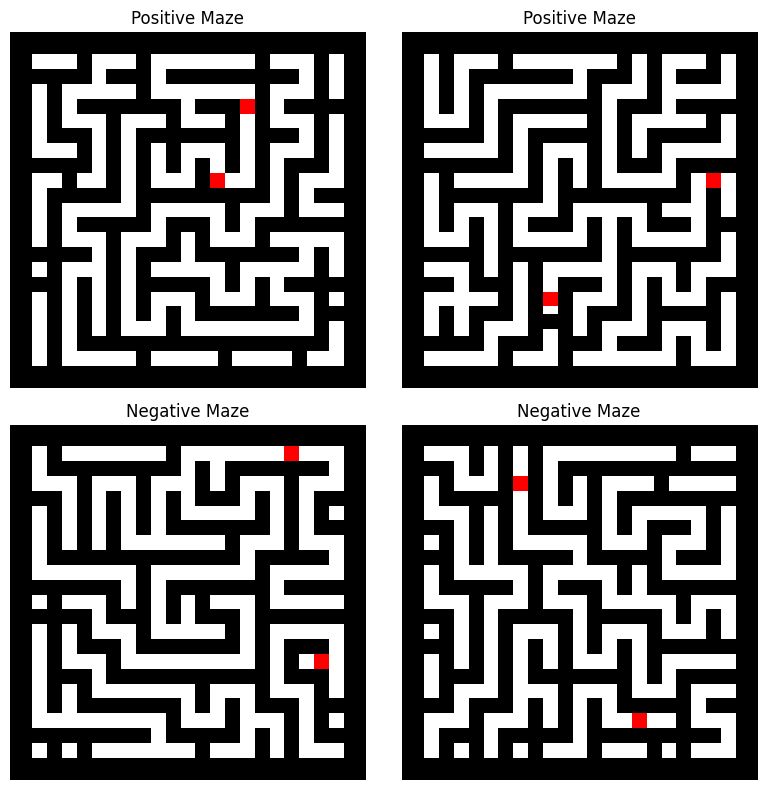

In [123]:
inputs = test_loader.dataset
sample_indices = [0, 5, 3, 1]

# Set up grid: 2 rows x 2 cols for 4 samples
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.flatten()

for ax, sample_idx in zip(axes, sample_indices):
    inp, label = inputs[sample_idx][0], inputs[sample_idx][1]
    ax.imshow(mazes.tensor_to_image(inp))
    if label == 1:
        ax.set_title("Positive Maze")
    else:
        ax.set_title("Negative Maze")
    ax.axis('off')

plt.tight_layout()
plt.show()

## Plot B - Accuracy over Time

In [124]:
classifier.to(device)
classifier.eval()

num_steps_to_try = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]

# Choose a subset of the test_loader (e.g., first N batches)
subset_batches = 10
subset_data = []
subset_labels = []
count = 0
for x, labels in test_loader:
    subset_data.append(x)
    subset_labels.append(labels)
    count += 1
    if count >= subset_batches:
        break

subset_data = torch.cat(subset_data, dim=0)
subset_labels = torch.cat(subset_labels, dim=0)

# Initialize arrays with correct shapes for the subset
accuracies = np.zeros((len(num_steps_to_try), len(subset_labels)))
step_accuracies = np.zeros(len(num_steps_to_try))  # Overall accuracy per step

for step_idx, num_steps in enumerate(num_steps_to_try):
    correct = 0
    total = 0
    sample_idx = 0  # Track position in dataset

    with torch.no_grad():
        for start in range(0, len(subset_labels), batch_size):
            end = start + batch_size
            x = subset_data[start:end].to(device)
            labels = subset_labels[start:end].to(device)

            logits = classifier(x, num_steps=num_steps)

            _, predicted = torch.max(logits, 1)
            current_batch_size = labels.size(0)

            # Update overall accuracy
            total += current_batch_size
            correct += (predicted == labels).sum().item()

            # Store individual sample accuracies
            batch_correct = (predicted == labels).cpu().numpy()
            accuracies[step_idx, sample_idx:sample_idx + current_batch_size] = batch_correct
            sample_idx += current_batch_size

    # Calculate and store overall accuracy for this step
    step_accuracies[step_idx] = correct / total
    # print(f"Steps {num_steps}: Accuracy = {step_accuracies[step_idx]:.4f}")

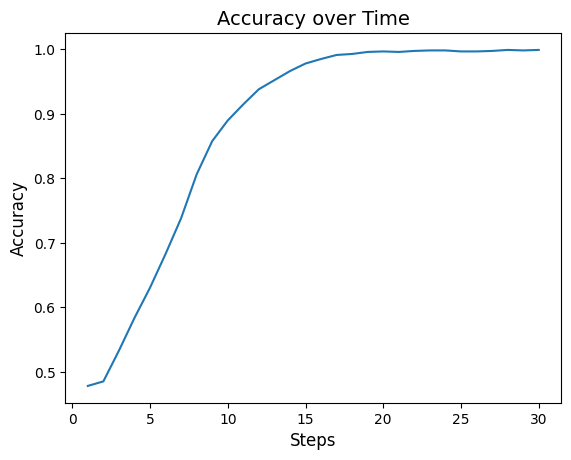

In [125]:
plt.plot(num_steps_to_try, np.mean(accuracies, axis=1))
plt.xlabel("Steps", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Accuracy over Time", fontsize=14)
plt.show()

## Plot C - Activity

/tmp/ipykernel_3040646/2534165316.py:165: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


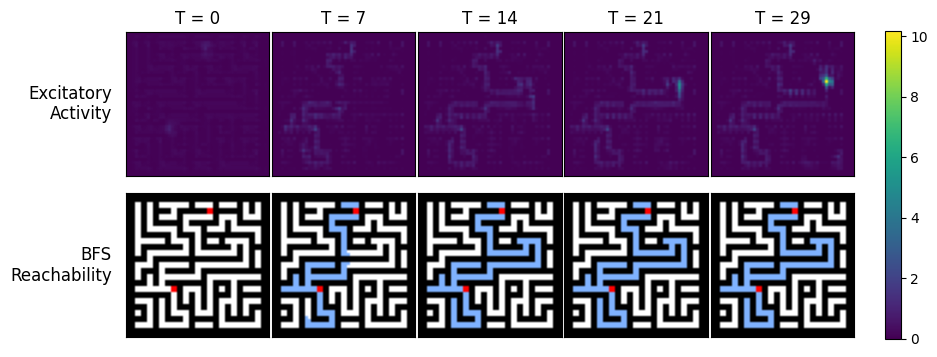

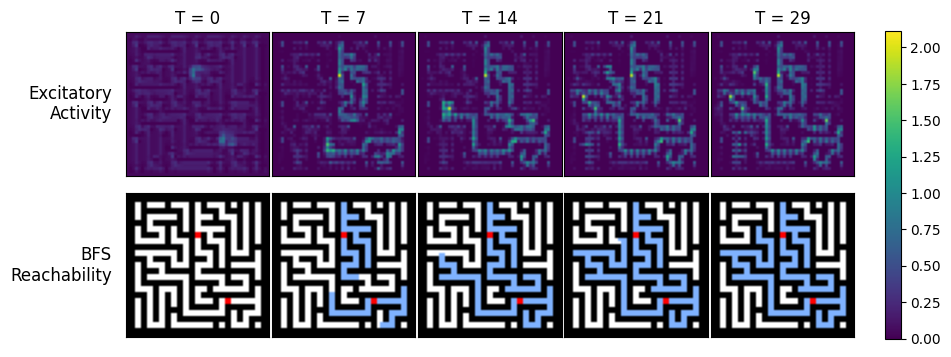

In [126]:
# ——— Plot settings ———
excitatory = True
n, m = 1, 5  # activity grid dims
sigma_filter = 1.0  # optional blur for weights
channels_to_plot = np.arange(8)
sample_indices = [12, 13]
do_highlight_self_kernel = False

inputs = test_loader.dataset

# Main plotting loop
for plot_idx, sample_idx in enumerate(sample_indices):
    inp, label = inputs[sample_idx][0], inputs[sample_idx][1]
    _, neuron_states, _ = model(inp.unsqueeze(0).to(device), num_steps=num_steps)
    activity = model.query_neuron_states(neuron_states, 0, 0 if excitatory else 1) \
               .detach().cpu()[0]  # shape (T, C)
    
    plot_mean_channel_activity(activity, n, m, inp)

## Plot D - Comparison to CNN

In [127]:
def cell_to_pixels(r, c):
    """Map a logical cell (r,c) to the 2×2 pixel block in a 48×48 grid."""
    return [(2*r + dr, 2*c + dc) for dr in (0, 1) for dc in (0, 1)]

def _base_u(cells=24, horiz=8, vert=4):
    """
    Build a 24×24 U‐maze open to the left, centered, with:
      - horizontal arms of length horiz+1
      - vertical connector of span vert+1
    """
    M = np.zeros((cells, cells), dtype=int)
    r0 = (cells - vert) // 2  # top arm row
    c0 = (cells - horiz) // 2 # leftmost column of arms

    M[r0,        c0 : c0 + horiz + 1] = 1
    M[r0 + vert, c0 : c0 + horiz + 1] = 1
    M[r0 : r0 + vert + 1, c0 + horiz] = 1
    return M

# --- helpers ---
def _logical_endpoints(base):
    endpoints = []
    H, W = base.shape
    for r, c in zip(*np.where(base == 1)):
        cnt = sum(
            0 <= r+dr < H and 0 <= c+dc < W and base[r+dr, c+dc] == 1
            for dr, dc in ((1,0),(-1,0),(0,1),(0,-1))
        )
        if cnt == 1:
            endpoints.append((r, c))
    return endpoints

def _ordered_path_through_U(base, ends):
    """Return the unique ordered path (list of (r,c)) along the U from ends[0] to ends[1]."""
    assert len(ends) == 2, "U should have exactly two endpoints"
    H, W = base.shape
    def nbrs(r,c):
        for dr,dc in ((1,0),(-1,0),(0,1),(0,-1)):
            rr, cc = r+dr, c+dc
            if 0 <= rr < H and 0 <= cc < W and base[rr,cc] == 1:
                yield (rr, cc)

    start, goal = ends
    path = [start]
    prev = None
    cur = start
    # Walk along the single path (degree≤2 everywhere)
    while cur != goal:
        candidates = [n for n in nbrs(*cur) if n != prev]
        if not candidates:
            break  # should not happen for a valid U
        nxt = candidates[0] if len(candidates) == 1 else (
            candidates[0] if candidates[0] != prev else candidates[1]
        )
        path.append(nxt)
        prev, cur = cur, nxt
    return path

def _cells_to_pixels(cells):
    return [pix for (r, c) in cells for pix in cell_to_pixels(r, c)]

def _expand_with_preidentified_endpoints(base_post, end_cells_pre):
    wall_cells = [tuple(rc) for rc in np.argwhere(base_post == 1)]
    wall_pixels = _cells_to_pixels(wall_cells)
    endpoint_pixels = _cells_to_pixels(end_cells_pre)
    return wall_pixels, endpoint_pixels

def _ablate_u_segment(base, *, length=None, frac=None, seed=None, protect_endpoints=True):
    """
    Zero out a contiguous segment along the U path.
    Choose via absolute `length` (cells) or `frac` of total path.
    """
    base = base.copy()
    ends = _logical_endpoints(base)
    path = _ordered_path_through_U(base, ends)
    L = len(path)
    if L == 0:
        return base

    if length is None:
        assert frac is not None and 0 < frac <= 1, "Provide length or 0<frac<=1"
        length = max(1, int(round(frac * L)))
    length = max(1, min(length, L))

    rng = np.random.default_rng(seed)

    # Respect endpoint protection by limiting start index range
    start_min = 1 if protect_endpoints else 0
    start_max = (L - length - 1) if protect_endpoints else (L - length)
    if start_max < start_min:
        # If the requested segment is too large to avoid endpoints, shrink it
        length = max(1, (L - 2) if protect_endpoints else L)
        start_max = (L - length - 1) if protect_endpoints else (L - length)
        start_min = min(start_min, start_max)

    start_idx = int(rng.integers(start_min, start_max + 1)) if start_max >= start_min else start_min
    seg = path[start_idx:start_idx + length]

    for rc in seg:
        base[rc] = 0
    return base

# --- U maze builders: endpoints BEFORE ablation; ablate a contiguous U chunk ---
def _apply_u_ablation(base, ablate_u=None, seed=None, protect_endpoints=True):
    if ablate_u is None or ablate_u == 0:
        return base
    if isinstance(ablate_u, int):
        return _ablate_u_segment(base, length=ablate_u, seed=seed, protect_endpoints=protect_endpoints)
    if isinstance(ablate_u, float):
        return _ablate_u_segment(base, frac=ablate_u, seed=seed, protect_endpoints=protect_endpoints)
    if isinstance(ablate_u, dict):
        mode = ablate_u.get('mode', 'segment')
        if mode != 'segment':
            raise ValueError("Only 'segment' mode is supported for U-specific ablation.")
        length = ablate_u.get('length', None)
        frac   = ablate_u.get('frac', None)
        seed   = ablate_u.get('seed', seed)
        protect = ablate_u.get('protect_endpoints', protect_endpoints)
        return _ablate_u_segment(base, length=length, frac=frac, seed=seed, protect_endpoints=protect)
    raise ValueError("ablate_u must be int (length), float (frac), or dict")

def maze_right(arm=12, vert=4, ablate_u=None, seed=None, protect_endpoints=True):
    base = _base_u(24, arm, vert)
    ends_pre = _logical_endpoints(base)
    base_post = _apply_u_ablation(base, ablate_u, seed, protect_endpoints)
    return _expand_with_preidentified_endpoints(base_post, ends_pre)

def maze_left(arm=12, vert=4, ablate_u=None, seed=None, protect_endpoints=True):
    base = np.fliplr(_base_u(24, arm, vert))
    ends_pre = _logical_endpoints(base)
    base_post = _apply_u_ablation(base, ablate_u, seed, protect_endpoints)
    return _expand_with_preidentified_endpoints(base_post, ends_pre)

def maze_up(arm=12, vert=4, ablate_u=None, seed=None, protect_endpoints=True):
    base = np.rot90(_base_u(24, arm, vert), k=1)
    ends_pre = _logical_endpoints(base)
    base_post = _apply_u_ablation(base, ablate_u, seed, protect_endpoints)
    return _expand_with_preidentified_endpoints(base_post, ends_pre)

def maze_down(arm=12, vert=4, ablate_u=None, seed=None, protect_endpoints=True):
    base = np.rot90(_base_u(24, arm, vert), k=-1)
    ends_pre = _logical_endpoints(base)
    base_post = _apply_u_ablation(base, ablate_u, seed, protect_endpoints)
    return _expand_with_preidentified_endpoints(base_post, ends_pre)

def connected_staircase_length(n=24, length=3, corner="tl", as_torch=False, dtype=np.uint8):
    """
    Build an n×n grid with a connected staircase:
      vertical segment of exactly `length` cells,
      then horizontal segment of exactly `length` cells,
      repeating until the grid edge is reached.
    The corner cell is shared between consecutive segments.

    Parameters
    ----------
    n : int
        Grid size (n×n).
    length : int
        Arm length (cells) for both vertical and horizontal segments (>=1).
        Each segment includes its starting corner cell.
    corner : {'tl','tr','bl','br'}
        Starting corner. The staircase moves inward:
          tl: down, then right (main-diagonal direction)
          tr: down, then left
          bl: up,   then right
          br: up,   then left
    as_torch : bool
        If True, return torch.FloatTensor; else NumPy array.
    dtype : np.dtype
        NumPy dtype when as_torch=False.

    Returns
    -------
    grid : np.ndarray or torch.Tensor
        n×n with 1s for the staircase and 0s elsewhere.
    """
    if length < 1:
        raise ValueError("length must be >= 1")

    g = np.zeros((n, n), dtype=dtype)

    # Start and directions
    if corner == "tl":
        r, c = 0, 0; v_down, h_right = True, True
    elif corner == "tr":
        r, c = 0, n-1; v_down, h_right = True, False
    elif corner == "bl":
        r, c = n-1, 0; v_down, h_right = False, True
    elif corner == "br":
        r, c = n-1, n-1; v_down, h_right = False, False
    else:
        raise ValueError("corner must be one of {'tl','tr','bl','br'}")

    def draw_vertical(r0, c0, L, down=True):
        """Draw L cells including (r0,c0). Return new (r,c) at far tip."""
        if down:
            r1 = min(n-1, r0 + (L - 1))
            g[r0:r1+1, c0] = 1
            return r1, c0
        else:
            r1 = max(0, r0 - (L - 1))
            g[r1:r0+1, c0] = 1
            return r1, c0

    def draw_horizontal(r0, c0, L, right=True):
        """Draw L cells including (r0,c0). Return new (r,c) at far tip."""
        if right:
            c1 = min(n-1, c0 + (L - 1))
            g[r0, c0:c1+1] = 1
            return r0, c1
        else:
            c1 = max(0, c0 - (L - 1))
            g[r0, c1:c0+1] = 1
            return r0, c1

    # Build connected Ls until neither segment adds anything new
    while True:
        r_prev, c_prev = r, c
        r, c = draw_vertical(r, c, length, down=v_down)
        r, c = draw_horizontal(r, c, length, right=h_right)

        # Stop if the tip didn't move (we're pinned at borders)
        if (r, c) == (r_prev, c_prev):
            break

    return torch.from_numpy(g.astype(np.float32))
    return g

base_input = np.zeros((24,24))

In [ ]:
def plot_accuracies(bioplnn_accuracies_pos, cnn_accuracies_pos, bioplnn_accuracies_neg, cnn_accuracies_neg):
    labels = ['BioPLNN', 'CNN']
    pos_accuracies = [bioplnn_accuracies_pos[0], cnn_accuracies_pos[0]]
    neg_accuracies = [bioplnn_accuracies_neg[0], cnn_accuracies_neg[0]]

    x = np.arange(len(labels))
    width = 0.35

    # Define custom colors: light blue and light greenish yellow
    light_blue = "#a3c9f7"  # BFS fill blue (same as used above)
    light_green_yellow = "#95DB88"

    fig, ax = plt.subplots()
    rects1 = ax.bar(x - width/2, pos_accuracies, width, label='Positive', color=light_blue)
    rects2 = ax.bar(x + width/2, neg_accuracies, width, label='Negative', color=light_green_yellow)

    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title('Classifier Accuracy by Model and Condition', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=12)
    ax.legend(fontsize=12)

    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.2f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom')

    autolabel(rects1)
    autolabel(rects2)

    plt.ylim(0, 1.10)
    plt.show()

In [4]:
def evaluate_classifier(classifier, steps_range, ablate=False):
    accuracies = []
    classifier.to(device)
    for num_steps in steps_range:
        print(num_steps)
        num_correct, total = 0, 0
        for arm in range(4, 15):
            for vert in range(4, 15):
                ablate_us = [4,5,6,7] if ablate else [None]
                for ablate_u in ablate_us:
                    for fn in (maze_left, maze_right, maze_up, maze_down):
                        kwargs = dict(arm=arm, vert=vert)
                        if ablate:
                            kwargs.update(dict(ablate_u=ablate_u, seed=1))
                        wall_pixels, input_pixels = fn(**kwargs)
                        wall_rows, wall_cols = zip(*wall_pixels)
                        input_rows, input_cols = zip(*input_pixels)
                        walls = base_input.copy().repeat(2, axis=0).repeat(2, axis=1)
                        walls[wall_rows, wall_cols] = 1
                        walls = np.stack([walls]*3, axis=0)
                        points = base_input.copy().repeat(2, axis=0).repeat(2, axis=1)
                        points[input_rows, input_cols] = 1
                        points = points[np.newaxis, ...]
                        inp_np = np.concatenate([walls, points], axis=0)
                        inp = torch.tensor(inp_np, dtype=torch.float32).to(device)
                        if "CNN" in classifier.__class__.__name__:
                            pred = classifier(inp.unsqueeze(0))
                        else:
                            pred, *_ = classifier(inp.unsqueeze(0), num_steps=num_steps, ablater=None if not ablate else None, return_activations=True)
                        correct_label = 0 if ablate else 1
                        if pred.argmax(dim=1).item() == correct_label:
                            num_correct += 1
                        total += 1
        acc = num_correct / total
        accuracies.append(acc)
        print(acc)
    return accuracies

# Run for normal and ablation conditions
bioplnn_accuracies_pos = evaluate_classifier(classifier, [20], ablate=False)
bioplnn_accuracies_neg = evaluate_classifier(classifier, [20], ablate=True)

cnn_accuracies_pos = evaluate_classifier(cnn_classifier, [20], ablate=False)
cnn_accuracies_neg = evaluate_classifier(cnn_classifier, [20], ablate=True)

NameError: name 'classifier' is not defined

In [3]:
plot_accuracies(bioplnn_accuracies_pos, cnn_accuracies_pos, bioplnn_accuracies_neg, cnn_accuracies_neg)

NameError: name 'plot_accuracies' is not defined

In [ ]:
def flip_random_connected_n(grid, n, rng=None, max_tries=500, in_place=False):
    """
    Zero out a random connected (4-neighbor) cluster of EXACTLY n cells that are 1s.
    If the sampled component has < n cells, retry with another start (up to max_tries).

    Parameters
    ----------
    grid : (H,W) np.ndarray of {0,1}
    n : int                   # target cluster size (>=1)
    rng : np.random.Generator # optional
    max_tries : int
    in_place : bool

    Returns
    -------
    out : np.ndarray
        Grid with the chosen n connected 1s flipped to 0s (or unchanged if impossible).
    """
    if rng is None:
        rng = np.random.default_rng()
    if n < 1:
        raise ValueError("n must be >= 1")
    H, W = grid.shape
    ones = np.argwhere(grid == 1)
    if ones.shape[0] < n:
        return grid if in_place else grid.copy()

    out = grid if in_place else grid.copy()

    def bfs_pick_n(r0, c0):
        """BFS within 1-cells; return list of up to n coords in one connected component."""
        if out[r0, c0] != 1:
            return []
        picked = []
        visited = np.zeros((H, W), dtype=bool)
        q = [(r0, c0)]
        visited[r0, c0] = True
        while q and len(picked) < n:
            r, c = q.pop(0)
            if out[r, c] == 1:
                picked.append((r, c))
                # enqueue 4-neighbors
                if r > 0   and not visited[r-1, c]: visited[r-1, c] = True; q.append((r-1, c))
                if r < H-1 and not visited[r+1, c]: visited[r+1, c] = True; q.append((r+1, c))
                if c > 0   and not visited[r, c-1]: visited[r, c-1] = True; q.append((r, c-1))
                if c < W-1 and not visited[r, c+1]: visited[r, c+1] = True; q.append((r, c+1))
        return picked

    # Try random starts until we find a component with at least n cells
    for _ in range(max_tries):
        r0, c0 = ones[rng.integers(len(ones))]
        picked = bfs_pick_n(r0, c0)
        if len(picked) == n:
            for r, c in picked:
                out[r, c] = 0
            return out
        # If component larger than n, we still returned exactly n via BFS order (connected).
        # If smaller, try another start.
    # If we couldn't find any component with >= n cells, return unchanged
    return out.to_numpy()


In [ ]:
def evaluate_staircase_classifier(classifier, device, ablate=False, steps_to_plot=np.arange(39, 40), show_plots=False):
    """
    Evaluate classifier accuracy on staircase variants for given steps.

    Args:
        classifier: The model to evaluate.
        device: Torch device.
        ablate: Whether to ablate (flip) 2 random connected wall cells.
        steps_to_plot: Iterable of num_steps to evaluate.
        show_plots: If True, show input images.

    Returns:
        List of accuracies for each num_steps in steps_to_plot.
    """
    accuracies = []
    classifier.to(device)

    for num_steps in steps_to_plot:
        print(num_steps)
        num_correct = 0
        total = 0
        for corner in ["br", "tr", "bl", "tl"]:
            for length in [2, 3, 4, 5]:
                for ablate_size in [2, 3, 4, 5]:
                    walls = connected_staircase_length(n=24, length=length, corner=corner).numpy()
                    if ablate:
                        walls = flip_random_connected_n(walls, 2)
                    walls = walls.repeat(2, axis=0).repeat(2, axis=1)
                    walls = np.stack([walls, walls, walls], axis=0)

                    points = np.zeros((24, 24))
                    if corner == "tr" or corner == "bl":
                        points[-1, 0] = 1
                        points[0, -1] = 1
                    else:
                        points[0, 0] = 1
                        points[-1, -1] = 1

                    points = points.repeat(2, axis=0).repeat(2, axis=1)
                    points = points[np.newaxis, ...]

                    # combine
                    inp = np.concatenate([walls, points], axis=0)
                    if show_plots:
                        plt.imshow(inp[0] + inp[-1]*2)
                        plt.show()

                    inp = torch.tensor(inp, dtype=torch.float32).to(device)

                    if "CNN" in classifier.__class__.__name__:
                        pred = classifier(inp.unsqueeze(0))
                    else:
                        pred, outs, neuron_states, fbs = classifier(
                            inp.unsqueeze(0), num_steps=num_steps, ablater=None, return_activations=True
                        )

                    correct_label = 0 if ablate else 1
                    correct = (pred.argmax(dim=1).item() == correct_label)
                    if correct:
                        num_correct += 1
                    total += 1

                    if not ablate:
                        break

        accuracy = num_correct / total
        accuracies.append(accuracy)
        print(accuracy)
    return accuracies

biolnn_pos_accuracies = evaluate_staircase_classifier(classifier, device, ablate=False, steps_to_plot=[20])
biolnn_neg_accuracies = evaluate_staircase_classifier(classifier, device, ablate=True, steps_to_plot=[20])

cnn_pos_accuracies = evaluate_staircase_classifier(cnn_classifier, device, ablate=False, steps_to_plot=[20])
cnn_neg_accuracies = evaluate_staircase_classifier(cnn_classifier, device, ablate=True, steps_to_plot=[20])

In [ ]:
plot_accuracies(biolnn_pos_accuracies, cnn_pos_accuracies, biolnn_neg_accuracies, cnn_neg_accuracies)

In [ ]:
# Plot all maze variants in a big grid
import random
arms = [5, 14]
verts = [4, 12]
maze_fns = [maze_left, maze_right, maze_up, maze_down]
n_rows = len(maze_fns)
n_cols = len(arms) * len(verts)

fig, axs = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 3*n_rows), squeeze=False)

col_idx = 0
for arm in arms:
    for vert in verts:
        for row_idx, fn in enumerate(maze_fns):
            # predesigned input
            wall_pixels, input_pixels = fn(arm=arm, vert=vert, ablate_u=random.randint(4, 8))
            wall_rows, wall_cols = zip(*wall_pixels)
            input_rows, input_cols = zip(*input_pixels)
            walls = base_input.copy()
            walls = walls.repeat(2, axis=0).repeat(2, axis=1)
            walls[wall_rows, wall_cols] = 1
            walls = np.stack([walls, walls, walls], axis=0)
            points = base_input.copy()
            points = points.repeat(2, axis=0).repeat(2, axis=1)
            points[input_rows, input_cols] = 1
            points = points[np.newaxis, ...]

            # combine
            inp_np = np.concatenate([walls, points], axis=0)
            inp = torch.tensor(inp_np, dtype=torch.float32)

            bg   = inp_np[0]
            over = inp_np[-1]

            ax = axs[row_idx, col_idx]
            ax.imshow(bg, cmap='gray', interpolation='none')

            over_norm = over.astype(float)
            vmax_o, vmin_o = np.nanmax(over_norm), np.nanmin(over_norm)
            over_norm = (over_norm - vmin_o) / (vmax_o - vmin_o) if vmax_o > vmin_o else np.zeros_like(over_norm)

            rgba = np.zeros((*over_norm.shape, 4), dtype=float)
            rgba[..., 0] = 1.0
            rgba[..., 3] = over_norm * 0.85
            ax.imshow(rgba, interpolation='none')

            ax.axis('off')
        col_idx += 1

plt.tight_layout()
plt.show()

In [ ]:
# Plot all maze variants in a big grid

n_rows = 4
n_cols = 4

fig, axs = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 3*n_rows), squeeze=False)

col_idx = 0
for corner in ["br", "tr", "bl", "tl"]:
    for row_idx, length in enumerate([2, 3, 4, 5]):
        walls = connected_staircase_length(n=24, length=length, corner=corner).numpy()
        walls = flip_random_connected_n(walls, np.random.randint(2, 5))
        walls = walls.repeat(2, axis=0).repeat(2, axis=1)
        walls = np.stack([walls, walls, walls], axis=0)

        points = np.zeros((24, 24))
        if corner == "tr" or corner == "bl":
            points[-1, 0] = 1
            points[0, -1] = 1
        else:
            points[0, 0] = 1
            points[-1, -1] = 1

        points = points.repeat(2, axis=0).repeat(2, axis=1)
        points = points[np.newaxis, ...]

        #combine
        inp = np.concatenate([walls, points], axis=0)

        bg   = inp[0]
        over = inp[-1]

        ax = axs[row_idx, col_idx]
        ax.imshow(bg, cmap='gray', interpolation='none')

        over_norm = over.astype(float)
        vmax_o, vmin_o = np.nanmax(over_norm), np.nanmin(over_norm)
        over_norm = (over_norm - vmin_o) / (vmax_o - vmin_o) if vmax_o > vmin_o else np.zeros_like(over_norm)

        rgba = np.zeros((*over_norm.shape, 4), dtype=float)
        rgba[..., 0] = 1.0
        rgba[..., 3] = over_norm * 0.85
        ax.imshow(rgba, interpolation='none')

        ax.axis('off')
    col_idx += 1

plt.tight_layout()
plt.show()

## Plot E - Time v Distance

### Refer to Time v Difficulty section in linear_decoding.ipynb

# Correlated Dots

In [5]:
## CORRELATED DOTS ##

wandb_name, checkpoint = "fancy-silence-24", 370 #BIOPLNN
# wandb_name, checkpoint = "glowing-deluge-31", 330 #CNN
wandb_name, checkpoint = "rosy-morning-40", 390 #Best, max_speed=1
# wandb_name, checkpoint = "eager-cosmos-37", 390 #Best, max_speed=5
# wandb_name, checkpoint = "easy-universe-51", 449 #loss all timesteps
# wandb_name, checkpoint = "true-sound-54", 599 #0.05-0.75
model, classifier, num_steps, cfg, state_dict = load_model_and_config(wandb_name, checkpoint)


# wandb_name, checkpoint = "laced-lake-56", 0 #0.05-0.75
# model, classifier, num_steps, cfg, state_dict = load_model_and_config(wandb_name, checkpoint)
# wandb_name, checkpoint = "true-sound-54", 599 #0.05-0.75
# model, classifier, num_steps, cfg, state_dict = load_model_and_config(wandb_name, checkpoint, full_cfg=cfg)


model.eval()
model.to(device)

classifier.eval()
classifier.to(device)

{'model_type': '1e1ii1a', 'model_config': {'rnn_kwargs': {'num_areas': 1, 'area_kwargs': [{'num_neuron_types': 2, 'num_neuron_subtypes': array([8, 4]), 'neuron_type_class': array(['excitatory', 'inhibitory'], dtype='<U10'), 'inter_neuron_type_connectivity': array([[1, 1, 0],
       [1, 1, 1],
       [1, 1, 0]]), 'in_size': (128, 128), 'in_channels': 1, 'out_channels': 8, 'inter_neuron_type_nonlinearity': array([['Identity', 'Identity', 'Identity'],
       ['Identity', 'Identity', 'Identity'],
       ['Identity', 'Identity', 'Identity']], dtype='<U8'), 'inter_neuron_type_spatial_extents': (5, 5), 'neuron_type_nonlinearity': 'ReLU'}]}, 'num_classes': 8, 'fc_dim': 512, 'dropout': 0.2}, 'lr': 0.0012, 'num_steps': None, 'max_epochs': 400, 'batch_size': 128, 'max_gradient': 5.0, 'scheduler': {'name': 'OneCycleLR', 'kwargs': {'pct_start': 0.15, 'anneal_strategy': 'cos', 'div_factor': 20.0}}, 'init_weights': 'none', 'seed': 4, 'dots_kwargs': {'n_frames': 40, 'resolution': (128, 128), 'correlat

/tmp/ipykernel_3040646/4144688288.py:58: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_locati

SpatiallyEmbeddedClassifier(
  (rnn): SpatiallyEmbeddedRNN(
    (areas): ModuleList(
      (0): SpatiallyEmbeddedArea(
        (out_nonlinearity): Identity()
        (neuron_type_nonlinearity): ModuleList(
          (0-1): 2 x ReLU()
        )
        (convs): ModuleDict(
          (0->0): Sequential(
            (0): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
            (1): Identity()
          )
          (0->1): Sequential(
            (0): Conv2d(1, 4, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
            (1): Identity()
          )
          (1->0): Sequential(
            (0): Conv2dRectify(8, 8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
            (1): Identity()
          )
          (1->1): Sequential(
            (0): Conv2dRectify(8, 4, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
            (1): Identity()
          )
          (2->0): Sequential(
            (0): Conv2dRectify(4, 8, kernel_size=(5, 5), stride=(1, 1), padding

## Plot A - Task

In [6]:
from PIL import Image
from IPython.display import display, clear_output
import imageio
import time

def _to_numpy_3d(frames):
    if torch is not None and isinstance(frames, torch.Tensor):
        frames = frames.detach().cpu().numpy()
    else:
        frames = np.asarray(frames)
    if frames.ndim != 3:
        raise ValueError(f"Expected a 3D array shaped (T, H, W); got shape {frames.shape}")
    return frames

def _scale_to_uint8(arr, vmin=None, vmax=None):
    arr = np.asarray(arr)
    if arr.dtype == np.uint8 and vmin is None and vmax is None:
        return arr
    if arr.dtype == bool:
        return (arr.astype(np.uint8) * 255)
    if vmin is None:
        vmin = float(np.nanmin(arr))
    if vmax is None:
        vmax = float(np.nanmax(arr))
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmax == vmin:
        vmin, vmax = 0.0, 1.0
    arr = (arr - vmin) / (vmax - vmin)
    arr = np.clip(arr, 0.0, 1.0)
    return (arr * 255.0 + 0.5).astype(np.uint8)

def _resize(u8_frame, scale):
    if int(scale) == 1:
        return u8_frame
    h, w = u8_frame.shape
    img = Image.fromarray(u8_frame, mode="L")
    img = img.resize((w*int(scale), h*int(scale)), resample=Image.NEAREST)
    return np.array(img, dtype=np.uint8)

def play_tensor(
    frames,
    fps=10,
    loop=1,
    per_frame=False,
    vmin=None,
    vmax=None,
    scale=1,
    save_path=None,
    save_as="mp4",  # "mp4" or "gif"
):
    """
    Play a 3D tensor as an animation in the notebook, and optionally save as MP4 or GIF.

    Args:
        frames: 3D array (T, H, W)
        fps: frames per second for playback and saving
        loop: number of times to loop the inline animation
        per_frame: if True, scale each frame independently
        vmin, vmax: value range for scaling
        scale: integer scaling factor for display/saving
        save_path: if not None, path to save animation (MP4 or GIF)
        save_as: "mp4" or "gif" (default "mp4")
    """
    frames = _to_numpy_3d(frames)
    T, H, W = frames.shape
    delay = 1.0 / max(1, int(fps))

    # compute once if global scaling
    if per_frame:
        frames_u8 = [_scale_to_uint8(f, vmin=vmin, vmax=vmax) for f in frames]
    else:
        use_vmin = vmin if vmin is not None else float(np.nanmin(frames))
        use_vmax = vmax if vmax is not None else float(np.nanmax(frames))
        frames_u8 = [_scale_to_uint8(f, vmin=use_vmin, vmax=use_vmax) for f in frames]

    # Inline preview
    for _ in range(max(1, int(loop))):
        for f in frames_u8:
            clear_output(wait=True)
            img = Image.fromarray(_resize(f, scale), mode="L")
            display(img)
            time.sleep(delay)
    clear_output(wait=True)

    # Save animation
    if save_path is not None:
        ext = save_path.lower().split('.')[-1]
        save_type = save_as.lower()
        if save_type not in ("mp4", "gif"):
            # Try to infer from extension
            if ext == "gif":
                save_type = "gif"
            else:
                save_type = "mp4"

        if save_type == "mp4":
            # 3-channel for compatibility
            frames_rgb = [np.repeat(_resize(f, scale)[..., None], 3, axis=2) for f in frames_u8]
            # v3: mimwrite; v2: get_writer
            if hasattr(imageio, "mimwrite"):  # imageio v3 style
                imageio.mimwrite(save_path, frames_rgb, fps=fps, codec="libx264", pixelformat="yuv420p")
            else:  # fallback for older versions
                with imageio.get_writer(save_path, fps=fps, codec="libx264", pixelformat="yuv420p") as w:
                    for fr in frames_rgb:
                        w.append_data(fr)
            print(f"Saved MP4 to {save_path}")
        elif save_type == "gif":
            # GIFs can be single-channel or 3-channel, but we'll use single-channel for grayscale
            frames_gif = [_resize(f, scale) for f in frames_u8]
            # imageio expects (H, W) or (H, W, 3) uint8 arrays
            duration = 1.0 / fps
            # Set loop=0 for infinite looping
            gif_kwargs = dict(format="GIF", duration=duration, loop=0)
            if hasattr(imageio, "mimsave"):
                imageio.mimsave(save_path, frames_gif, **gif_kwargs)
            else:
                imageio.mimwrite(save_path, frames_gif, **gif_kwargs)
            print(f"Saved GIF to {save_path}")
        else:
            raise ValueError(f"Unknown save_as type: {save_type}")


In [7]:
n_frames = 40
resolution = (128, 128)
correlation = 0.05
max_speed = 1
samples_per_epoch = 20
fps = 40

for correlation in [0.1, 0.25, 0.5, 0.75]:
    train_loader, test_loader = initialize_dataloader(
            seed=42, dataset="correlated_dots",
            resolution=resolution, n_frames=n_frames, correlation=correlation, max_speed=max_speed, samples_per_epoch=samples_per_epoch)
    inputs, labels  = list(train_loader)[0]
    frames = inputs[0, :, 0]
    play_tensor(frames, fps=fps, scale=4, save_path=f"Corr_{correlation}.gif", save_as="gif")

Saved GIF to Corr_0.75.gif


## Plot ? - Visualization and Fitting of Dynamics

### Dataloading Helpers

In [6]:
def keep_only_label_from_loader(loader, target_labels, batch_size=None, shuffle=False):
    xs, ys = [], []
    for x, y in loader:
        # make labels 1-D over batch
        if y.ndim > 1:
            # if one-hot/probabilities, reduce to class id
            if y.size(-1) > 1:
                y_flat = y.argmax(dim=-1)
            else:
                y_flat = y.squeeze(-1)
        else:
            y_flat = y

        mask = False
        for label in target_labels:
            mask = mask | (y_flat == label)
        if mask.any():
            xs.append(x[mask, ...])                # index batch dim only
            ys.append(y_flat[mask])

    X = torch.cat(xs, dim=0)
    Y = torch.cat(ys, dim=0)
    ds = TensorDataset(X, Y)
    return DataLoader(
        ds,
        batch_size or loader.batch_size,
        shuffle=shuffle,
        num_workers=loader.num_workers,
        pin_memory=loader.pin_memory,
        drop_last=loader.drop_last,
    )

def _balance_classes(activations, decisions, seed=42):
    """
    Downsample each class to match the smallest class size.
    """
    rng = np.random.default_rng(seed)
    activations = np.asarray(activations)
    decisions = np.asarray(decisions)

    if decisions.shape[0] != activations.shape[0]:
        raise ValueError("decisions must have length == activations.shape[0] (one label per row).")

    unique_classes, counts = np.unique(decisions, return_counts=True)
    min_count = counts.min()

    balanced_idx = []
    for cls in unique_classes:
        cls_idx = np.where(decisions == cls)[0]
        chosen = rng.choice(cls_idx, min_count, replace=False)
        balanced_idx.append(chosen)

    balanced_idx = np.concatenate(balanced_idx)
    rng.shuffle(balanced_idx)

    return activations[balanced_idx], decisions[balanced_idx]

### Activation Loading and PCA Functions

In [105]:
# ----- MEM UTILS -----
def _bytes(n):
    for unit in ["B","KB","MB","GB","TB"]:
        if n < 1024: return f"{n:.2f} {unit}"
        n /= 1024
    return f"{n:.2f} PB"

def _cpu_rss_bytes():
    try:
        import psutil
        return psutil.Process(os.getpid()).memory_info().rss
    except Exception:
        # Fallback: resource gets maxrss; not perfect, but better than nothing
        try:
            import resource
            r = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
            # macOS reports bytes, Linux reports KB
            return r if r > 10**9 else r * 1024
        except Exception:
            return 0

def _cuda_bytes():
    if torch.cuda.is_available():
        dev = torch.cuda.current_device()
        alloc = torch.cuda.memory_allocated(dev)
        reserv = torch.cuda.memory_reserved(dev)
        max_alloc = torch.cuda.max_memory_allocated(dev)
        return alloc, reserv, max_alloc
    return 0, 0, 0

def log_mem(tag):
    rss = _cpu_rss_bytes()
    alloc, reserv, max_alloc = _cuda_bytes()
    msg = (
        f"[{time.strftime('%H:%M:%S')}] {tag} | "
        f"CPU RSS: {_bytes(rss)} "
        f"| CUDA alloc: {_bytes(alloc)} "
        f"reserved: {_bytes(reserv)} "
        f"peak: {_bytes(max_alloc)}"
    )
    print(msg, flush=True)

def estimate_host_bytes(num_samples, num_steps, dim, store_inputs=True, dtype_bytes=4):
    """
    Rough lower bound of arrays you preallocate (not counting transient copies).
    e_a: (N, T, 8, dim, dim) float32
    final_inputs: (N, T, 1, 128, 128) float32 if store_inputs
    """
    e_bytes = num_samples * num_steps * 8 * dim * dim * dtype_bytes
    fi_bytes = num_samples * num_steps * 1 * 128 * 128 * dtype_bytes if store_inputs else 0
    return e_bytes + fi_bytes

# ----- YOUR FUNCTION WITH MEM LOGGING -----
def get_activations(model, classifier, num_samples, loader, decision_step, num_steps=20, dim=48, device=None, memory_monitor=False, precision="float32"):
    if device is None:
        device = next(model.parameters()).device

    # quick estimate up-front
    approx = estimate_host_bytes(num_samples, num_steps, dim, store_inputs=True, dtype_bytes=4)
    print(f"[estimate] Lower-bound host memory footprint (preallocs only): {_bytes(approx)}", flush=True)

    if memory_monitor:
        log_mem("start")

    # choose a sorted subset of indices
    all_indices = np.arange(len(loader.dataset))
    subset_indices = np.random.choice(all_indices, size=num_samples, replace=False)
    subset_indices = np.sort(subset_indices)

    # wrap dataset
    subset_dataset = Subset(loader.dataset, subset_indices)

    # mirror original loader settings where possible
    dataloader = DataLoader(
        subset_dataset,
        batch_size=loader.batch_size,
        shuffle=False,  # keep consistent ordering for preallocation fill
        num_workers=getattr(loader, "num_workers", 0),
        pin_memory=getattr(loader, "pin_memory", False),
        drop_last=False
    )

    # preallocate
    if precision == "float16":
        dtype = np.float16
    elif precision == "float32":    
        dtype = np.float32
    else:
        raise ValueError(f"Unknown precision: {precision}")
        
    e_a = np.zeros((num_samples, num_steps, 8, dim, dim), dtype=dtype)
    i_a = None  # np.zeros((num_samples, num_steps, 4, dim, dim), dtype=np.float32)
    o_a = None  # np.zeros((num_samples, num_steps, 8, dim, dim), dtype=np.float32)
    decisions = np.zeros((num_samples,), dtype=np.int64)

    if memory_monitor:
        log_mem("after preallocs")

    model.eval()
    classifier.eval()
    classifier.to(device)

    final_labels = []

    # CUDA peak stats baseline
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    sample_idx = 0
    with torch.no_grad():
        for batch_idx, (batch_inputs, labels) in enumerate(tqdm(dataloader)):
            if memory_monitor:
                log_mem(f"batch {batch_idx} - fetched from loader")

            bsz = batch_inputs.shape[0]

            # move to device
            batch_inputs = batch_inputs.to(device, non_blocking=True)
            if memory_monitor:
                log_mem(f"batch {batch_idx} - after to(device)")

            # forward core model
            batch_output_states, batch_neuron_states, batch_feedback_states = model(
                batch_inputs, num_steps=num_steps
            )
            if memory_monitor:
                log_mem(f"batch {batch_idx} - after model()")

            # collect outputs on CPU
            # NOTE: .cpu().numpy() creates a *new* CPU array (extra RAM). Track this explicitly.
            o = batch_output_states[0].detach().cpu()  # (B, T, 8, dim, dim)
            if memory_monitor:
                log_mem(f"batch {batch_idx} - after o.cpu() (before numpy)")

            # if you don't need numpy immediately, stay in torch and convert when writing:
            o_np = o.numpy()  # temp CPU copy
            if memory_monitor:
                log_mem(f"batch {batch_idx} - after o.numpy()")

            e_t = model.query_neuron_states(batch_neuron_states, 0, 0).detach().cpu()
            if memory_monitor:
                log_mem(f"batch {batch_idx} - after e.cpu() (before numpy)")
            e = e_t.numpy()
            if memory_monitor:
                log_mem(f"batch {batch_idx} - after e.numpy()")

            i_t = model.query_neuron_states(batch_neuron_states, 0, 1).detach().cpu()
            if memory_monitor:
                log_mem(f"batch {batch_idx} - after i.cpu() (before numpy)")
            i = i_t.numpy()
            if memory_monitor:
                log_mem(f"batch {batch_idx} - after i.numpy()")

            # decisions (GPU -> small CPU copy)
            pred = classifier(batch_inputs, num_steps=decision_step)
            dec = torch.argmax(pred, dim=-1).detach().cpu().numpy()
            if memory_monitor:
                log_mem(f"batch {batch_idx} - after classifier + argmax")

            # write into preallocated buffers
            sl = slice(sample_idx, sample_idx + bsz)
            e_a[sl, :, :, :, :] = e
            # if i_a is enabled, uncomment this line:
            # i_a[sl, :, :, :, :] = i
            # if o_a is enabled, uncomment this line:
            # o_a[sl, :, :, :, :] = o_np
            decisions[sl] = dec
            final_labels.extend(labels.flatten().tolist())
            if memory_monitor:
                log_mem(f"batch {batch_idx} - after writes to preallocs")

            # ---- CLEAN UP TRANSIENTS to release host RAM ----
            del o, o_np, e_t, e, i_t, i, pred, dec
            del batch_output_states, batch_neuron_states, batch_feedback_states
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            gc.collect()
            if memory_monitor:
                log_mem(f"batch {batch_idx} - after gc/empty_cache")

            sample_idx += bsz

    if memory_monitor:
        log_mem("end")
    return {
        "e_a": e_a,
        "i_a": i_a,
        "o_a": o_a,
        "decisions": decisions,
        "labels": np.array(final_labels, dtype=np.int64),
    }


# def get_activations(model, classifier, num_samples, loader, decision_step, num_steps=20, dim=48, device=None, directions=None):
#     if device is None:
#         device = next(model.parameters()).device

#     # choose a sorted subset of indices
#     all_indices = np.arange(len(loader.dataset))
#     subset_indices = np.random.choice(all_indices, size=num_samples, replace=False)
#     subset_indices = np.sort(subset_indices)

#     # wrap dataset
#     subset_dataset = Subset(loader.dataset, subset_indices)

#     # mirror original loader settings where possible
#     dataloader = DataLoader(
#         subset_dataset,
#         batch_size=loader.batch_size,
#         shuffle=False,  # keep consistent ordering for preallocation fill
#         num_workers=getattr(loader, "num_workers", 0),
#         pin_memory=getattr(loader, "pin_memory", False),
#         drop_last=False
#     )

#     # preallocate
#     # e_a = np.zeros((num_samples, num_steps, 8, dim, dim), dtype=np.float32)
#     # i_a = np.zeros((num_samples, num_steps, 4, dim, dim), dtype=np.float32)
#     # o_a = np.zeros((num_samples, num_steps, 8, dim, dim), dtype=np.float32)
#     e_a = []
#     i_a = []
#     o_a = []
#     decisions = []

#     model.eval()
#     classifier.eval()
#     classifier.to(device)

#     final_labels = []
#     final_inputs = []

#     with torch.no_grad():
#         for batch_inputs, labels in tqdm(dataloader):
#             bsz = batch_inputs.shape[0]
            
#             batch_inputs = batch_inputs.to(device, non_blocking=True)
#             # core model forward once
#             batch_output_states, batch_neuron_states, batch_feedback_states = model(
#                 batch_inputs, num_steps=num_steps
#             )

#              # --- decisions in the same pass ---
#             # your original code called classifier(batch_inputs, num_steps=decision_step) and argmax over last dim
#             pred = classifier(batch_inputs, num_steps=decision_step)            # (B, num_classes) or similar
#             dec = torch.argmax(pred, dim=-1).detach().cpu().numpy()            # (B,)

#             # --- collect O ---
#             # your original code: batch_output_states[0] (shape: [B, T, 8, H, W])
#             o = batch_output_states[0].detach().cpu().numpy()  # (B, T, 8, dim, dim)

#             # --- collect E and I via query_neuron_states ---
#             # your original code: query_neuron_states(states, layer_idx, 0 for 'e', 1 for 'i')
#             e = model.query_neuron_states(batch_neuron_states, 0, 0).detach().cpu().numpy()  # (B, T, 8, dim, dim)
#             i = model.query_neuron_states(batch_neuron_states, 0, 1).detach().cpu().numpy() # (B, T, 4, dim, dim)

#             for i in range(bsz):
#                 if directions is not None:
#                     decision = dec[i]
#                     if decision in directions:
#                         final_labels.append(labels[i].item())
#                         final_inputs.append(batch_inputs[i].detach().cpu().numpy())
#                         decisions.append(decision)
#                         e_a.append(e[i])
#                         # i_a.append(i[i])
#                         # o_a.append(o[i])
#                 else:
#                     final_labels.append(labels[i].item())
#                     final_inputs.append(batch_inputs[i].detach().cpu().numpy())
#                     decisions.append(dec[i])
#                     e_a.append(e[i])
#                     # i_a.append(i[i])
#                     # o_a.append(o[i])
            
#             print(len(e_a))

#     return np.array(e_a), np.array(i_a), np.array(o_a), np.array(decisions), np.array(final_inputs), np.array(final_labels)

def get_decisions(classifier, dataloader, decision_step, device=None):
    if device is None:
        device = next(classifier.parameters()).device

    num_samples = len(dataloader.dataset)
    decisions = np.zeros((num_samples,), dtype=np.int64)

    classifier.eval()
    classifier.to(device)

    sample_idx = 0
    with torch.no_grad():
        for batch_inputs, _labels in tqdm(dataloader):
            bsz = batch_inputs.shape[0]
            batch_inputs = batch_inputs.to(device, non_blocking=True)
            # --- decisions in the same pass ---
            # your original code called classifier(batch_inputs, num_steps=decision_step) and argmax over last dim
            pred = classifier(batch_inputs, num_steps=decision_step)            # (B, num_classes) or similar
            dec = torch.argmax(pred, dim=-1).detach().cpu().numpy()            # (B,)

            # write into preallocated buffers
            sl = slice(sample_idx, sample_idx + bsz)
            decisions[sl] = dec
            sample_idx += bsz

    return decisions

class PCTrajectoryPlotter:
    """
    Fit PCA on (N, T, D) activations and plot trajectories using the fitted PCA.

    Usage:
        p = PCTrajectoryPlotter(max_components=10, random_state=0)
        p.fit(activations_train, decisions_train, balance_for_fit=False)
        p.plot(activations_val, decisions_val, n_components=2, ...)
        p.plot(activations_val, decisions_val, n_components=3, ...)
        p.plot(activations_val, decisions_val, n_components=5, ...)
    Key behaviors:
      - PCA is fit ONCE via `.fit(...)` with max_components. Later `.plot(...)` calls reuse it and can select n_components <= max_components.
      - You can pass different activations/decisions to `.plot(...)`.
      - Class color mapping is fixed based on classes seen at fit-time.
      - Overlay exemplars can be restricted to a subset of classes via `overlay_classes`.
      - plot_all_endpoints scatters the ENDPOINT of *all* trials, regardless of other settings.
    """

    def __init__(self, max_components=None, n_components=None, random_state=0):
        # Backward compatibility: n_components is an alias for max_components if max_components is not given
        if max_components is None and n_components is not None:
            max_components = n_components
        self.max_components = max_components
        self.random_state = random_state

        # For backward compatibility, keep n_components as a property
        self.n_components = max_components

        # PCA will be fit with max_components (or all if None)
        self.pca = None
        self.fitted_ = False

        # Fitted metadata
        self.classes_ = None            # sorted unique class values (as seen in decisions at fit time)
        self.class_to_index_ = None     # mapping from class value -> integer index
        self.color_map_ = None          # mapping from class index -> rgba
        self.cmap_name = 'viridis'
        self.fit_collapsed_ = False
        self._fit_D = None              # Number of features at fit time

    # ----------------------- Core utilities -----------------------

    @staticmethod
    def _check_inputs(A, y):
        A = np.asarray(A)
        y = np.asarray(y)
        assert A.ndim == 3, f"activations must be (N,T,D); got {A.shape}"
        N, T, D = A.shape
        assert y.shape[0] == N, f"decisions length {y.shape[0]} must match N {N}"
        return A, y, N, T, D

    @staticmethod
    def _balance_indices(y_num, rng):
        counts = np.bincount(y_num)
        k_bal = counts[counts > 0].min()
        uniq = np.unique(y_num)
        keep = np.concatenate([
            rng.choice(np.where(y_num == c)[0], k_bal, replace=False) for c in uniq
        ])
        keep.sort()
        return keep

    def _build_color_map(self, uniq_indices):
        cmap = plt.get_cmap(self.cmap_name)
        if len(uniq_indices) <= 1:
            return {uniq_indices[0]: cmap(0.5)}
        return {c: cmap(i / max(1, len(uniq_indices) - 1)) for i, c in enumerate(uniq_indices)}

    def _resolve_overlay_class_indices(self, overlay_classes):
        """Convert overlay_classes (values) to internal indices used at *plot time*.
           Any classes not seen at fit time are ignored silently."""
        if overlay_classes is None:
            # All fit-time classes
            return set(range(len(self.classes_)))
        out = set()
        for c in overlay_classes:
            if c in self.class_to_index_:
                out.add(self.class_to_index_[c])
        return out

    # ----------------------- Fit / Transform -----------------------

    def fit(self, activations, decisions, *, balance_for_fit=False, collapse_to_class_means=False):
        """
        Fit PCA on (N,T,D) activations.
          - balance_for_fit=True balances class counts before PCA.
          - collapse_to_class_means=True fits PCA on per-class mean trajectories only.
        """
        from sklearn.decomposition import PCA

        rng = np.random.default_rng(self.random_state)
        A, y, N, T, D = self._check_inputs(activations, decisions)
        self._fit_D = D

        # establish classes at fit time
        classes, y_num = np.unique(y, return_inverse=True)
        self.classes_ = classes
        self.class_to_index_ = {c: i for i, c in enumerate(classes)}

        if collapse_to_class_means:
            # one mean trajectory per class
            A_means = []
            for c in np.unique(y_num):
                idx = np.where(y_num == c)[0]
                A_means.append(A[idx].mean(axis=0))  # (T,D)
            A_fit = np.stack(A_means, axis=0)  # (C,T,D)
            X_fit = A_fit.reshape(-1, D)
            self.fit_collapsed_ = True
        else:
            if balance_for_fit:
                counts = np.bincount(y_num)
                k_bal = counts[counts > 0].min()
                keep = np.concatenate([
                    rng.choice(np.where(y_num == c)[0], k_bal, replace=False) for c in np.unique(y_num)
                ])
                keep.sort()
                A = A[keep]
            X_fit = A.reshape(-1, D)
            self.fit_collapsed_ = False

        # If max_components is None, use all possible components (D)
        n_components = self.max_components if self.max_components is not None else min(X_fit.shape[0], D)
        self.pca = PCA(n_components=n_components, random_state=self.random_state)
        self.pca.fit(X_fit)
        uniq_indices = np.arange(len(classes))
        self.color_map_ = self._build_color_map(uniq_indices)
        self.fitted_ = True
        return self

    def transform(self, activations, n_components=None):
        """
        Project (N,T,D) activations into PC space using fitted PCA.
        n_components: number of PCs to return (<= max_components fit at .fit time).
        """
        assert self.fitted_, "Call .fit(...) first."
        A = np.asarray(activations)
        assert A.ndim == 3
        N, T, D = A.shape
        if D != self._fit_D:
            raise ValueError(f"Input feature dimension {D} does not match fit-time dimension {self._fit_D}")
        pcs_all = self.pca.transform(A.reshape(-1, D)).reshape(N, T, -1)
        # Determine how many components to return
        if n_components is None:
            n_components = self.max_components if self.max_components is not None else pcs_all.shape[-1]
        if n_components > pcs_all.shape[-1]:
            raise ValueError(f"Requested n_components={n_components} > max_components fit ({pcs_all.shape[-1]})")
        return pcs_all[..., :n_components]

    # ----------------------- Plot helpers -----------------------

    def _pick_indices_per_class(self, y_num, pcs_trials, k, mode, overlay_class_indices, rng):
        """Pick exemplar indices per class using ENDPOINT distance (closest/farthest/random)."""
        uniq = np.unique(y_num)
        chosen = []
        for c in uniq:
            if c not in overlay_class_indices:
                continue
            idx = np.where(y_num == c)[0]
            if k <= 0 or k >= len(idx):
                chosen.extend(idx); continue
            pcs_c = pcs_trials[idx]  # [Nc, T, C]
            mean_end = pcs_c[:, -1, :].mean(axis=0)
            d_end = ((pcs_c[:, -1, :] - mean_end) ** 2).sum(axis=1)
            if mode == "closest":
                sel_local = np.argsort(d_end)[:k]
            elif mode == "farthest":
                sel_local = np.argsort(d_end)[-k:]
            elif mode == "random":
                sel_local = rng.choice(len(idx), size=k, replace=False)
            else:
                raise ValueError("overlay_mode must be 'closest', 'farthest', or 'random'")
            chosen.extend(np.array(idx)[sel_local])
        return sorted(chosen)

    def _scatter_all_endpoints(self, ax, pcs_trials, y_num, s=16, a=0.35, n_components=None, name_by_label=None):
        """Scatter ENDPOINT (t=T-1) for all trials (2D or 3D)."""
        uniq = np.unique(y_num)
        for c in uniq:
            ends = pcs_trials[y_num == c, -1, :]  # [Nc, C]
            col = self.color_map_.get(c, (0.5, 0.5, 0.5, 0.6))  # neutral if unseen at fit
            if n_components == 2:
                ax.scatter(ends[:, 0], ends[:, 1], s=s, marker='o', alpha=a, color=col) #, label=f"class {name_by_label[c]}")
            else:
                ax.scatter(ends[:, 0], ends[:, 1], ends[:, 2], s=s, marker='o', alpha=a, color=col) #, label=f"class {name_by_label[c]}")

    def _plot_exemplars(self, ax, pcs_trials, y_num, idxs, alpha=0.35, extra_point_timestep=None, n_components=None, name_by_label=None):
        """Plot exemplar trajectories for provided indices (2D or 3D)."""
        for i in idxs:
            c = y_num[i]
            col = self.color_map_.get(c, (0.5, 0.5, 0.5, 0.6))
            if n_components == 2:
                xy = pcs_trials[i, :, :2]
                ax.plot(xy[:, 0], xy[:, 1], '-', lw=1.0, alpha=alpha, color=col) #, label=f"class {name_by_label[c]}")
                ax.scatter(xy[0, 0], xy[0, 1], s=80, marker='*', color=col, alpha=alpha)
                ax.scatter(xy[-1, 0], xy[-1, 1], s=80, marker='o', color=col, alpha=alpha)
                if extra_point_timestep is not None:
                    ax.scatter(xy[extra_point_timestep, 0], xy[extra_point_timestep, 1], s=80, marker='o', color=col, alpha=alpha)
            else:
                xyz = pcs_trials[i, :, :3]
                ax.plot(xyz[:, 0], xyz[:, 1], xyz[:, 2], '-', lw=1.0, alpha=alpha, color=col) #, label=f"class {name_by_label[c]}")
                ax.scatter(xyz[0, 0], xyz[0, 1], xyz[0, 2], s=80, marker='*', color=col, alpha=alpha)
                ax.scatter(xyz[-1, 0], xyz[-1, 1], xyz[-1, 2], s=80, marker='o', color=col, alpha=alpha)
                if extra_point_timestep is not None:
                    ax.scatter(xyz[extra_point_timestep, 0], xyz[extra_point_timestep, 1], xyz[extra_point_timestep, 2], s=80, marker='o', color=col, alpha=alpha)

    # ----------------------- Plot -----------------------

    def plot_variance_explained(self, activations=None, decisions=None, show=True):
        """Plot the variance explained by each principal component."""
        if not self.fitted_:
            raise RuntimeError("Call .fit(...) before .plot_variance_explained(...)")
        pca = self.pca
        explained_variance = pca.explained_variance_ratio_
        plt.plot(explained_variance)
        plt.xlabel("Principal Component")
        plt.ylabel("Variance Explained")
        if show:
            plt.show()
        return explained_variance

    def plot(
        self,
        activations,
        decisions,
        *,
        n_components=None,
        title=None,
        balance=False,                # balance for the *plotting subset* (does not change PCA)
        per_class_mean=True,
        plot_trajectory=True,
        collapse_to_class_means=False,
        overlay_examples_k=0,
        overlay_mode="closest",       # 'closest'|'farthest'|'random'
        overlay_classes=None,         # list of class values from decisions; None => all fitted classes
        plot_all_endpoints=False,
        alpha=0.5,
        lw=1.5,
        random_state=None,            # optional override for picking exemplars
        show=True,                    # set False if you want to compose multiple plots
        return_data=False,            # return (pcs_used, pcs_means or None),
        extra_point_timestep=None,
        ax=None,                       # NEW: axes to plot into, if not None
        label_segments_with_timesteps=False,  # NEW: If True, label each segment with its timestep (start-end)
        selected_trials=None,
    ):
        """
        Plot trajectories for a (possibly different) dataset using the already-fitted PCA.
        n_components: number of PCs to use for plotting (2, 3, or more, up to max_components fit at .fit time).
        ax: matplotlib Axes (2D or 3D) to plot into. If None, a new figure/axes is created.
        label_segments_with_timesteps: If True, label each segment (between two points) with its timestep index.
        """
        assert self.fitted_, "Call .fit(...) before .plot(...)."

        # Default n_components: 2 if not specified
        if n_components is None:
            n_components = 2
        if n_components > self.pca.components_.shape[0]:
            raise ValueError(f"Requested n_components={n_components} > max_components fit ({self.pca.components_.shape[0]})")

        rng = np.random.default_rng(self.random_state if random_state is None else random_state)
        A, y, N, T, D = self._check_inputs(activations, decisions)

        # Map y (values) to fit-time class indices; unseen classes get index -1
        y_idx = np.array([self.class_to_index_.get(v, -1) for v in y], dtype=int)
        if np.any(y_idx < 0):
            # Warn once in a non-intrusive way (comment-friendly)
            # print("[PCTrajectoryPlotter] Warning: some classes were unseen at fit; using neutral color.")
            pass

        # Optional balancing for plotting set only
        if balance and not collapse_to_class_means:
            keep = self._balance_indices(np.clip(y_idx, 0, None), rng)  # clip to avoid negatives in bincount
            A = A[keep]
            y_idx = y_idx[keep]
            N = A.shape[0]

        # Transform with fitted PCA
        pcs_trials = self.transform(A, n_components=n_components)  # (N, T, n_components)

        # Legend labels based on fit-time classes only
        uniq_fit = np.arange(len(self.classes_))
        name_by_label = {i: str(self.classes_[i]) for i in uniq_fit}

        # Resolve overlay class set (in fit-time index space)
        overlay_class_indices = self._resolve_overlay_class_indices(overlay_classes)

        # -- Collapsed to class means --
        if collapse_to_class_means:
            # Build means over *current* data by fit-time class index
            uniq_current = np.unique(y_idx[y_idx >= 0])  # only known classes
            if len(uniq_current) == 0:
                raise ValueError("No samples with classes seen at fit-time; cannot compute class means.")
            T_ = pcs_trials.shape[1]
            pcs_means = np.zeros((len(uniq_fit), T_, n_components), dtype=pcs_trials.dtype)

            for c in uniq_fit:
                idx = np.where(y_idx == c)[0]
                if len(idx) > 0:
                    pcs_means[c] = pcs_trials[idx].mean(axis=0)
                else:
                    pcs_means[c] = np.nan  # no samples for this class in current data

            if n_components == 2:
                if ax is None:
                    fig, ax_ = plt.subplots(figsize=(6, 4))
                    ax = ax_
                # Exemplars first (subset of classes), if requested
                if overlay_examples_k > 0:
                    idxs = self._pick_indices_per_class(np.clip(y_idx, 0, None), pcs_trials,
                                                        overlay_examples_k, overlay_mode,
                                                        overlay_class_indices, rng)
                    self._plot_exemplars(ax, pcs_trials, np.clip(y_idx, 0, None), idxs, alpha=min(alpha, 0.75), extra_point_timestep=extra_point_timestep, n_components=n_components, name_by_label=name_by_label)
                if selected_trials is not None:
                    print(selected_trials)
                    self._plot_exemplars(ax, pcs_trials, np.clip(y_idx, 0, None), selected_trials, alpha=min(alpha, 0.75), extra_point_timestep=extra_point_timestep, n_components=n_components, name_by_label=name_by_label)
                # All endpoints cloud
                if plot_all_endpoints:
                    self._scatter_all_endpoints(ax, pcs_trials, np.clip(y_idx, 0, None), s=18, a=0.75, n_components=n_components)

                for c in uniq_fit:
                    col = self.color_map_.get(c, (0.6, 0.6, 0.6, 0.9))
                    m = pcs_means[c]
                    if np.isnan(m).any():
                        continue
                    ax.plot(m[:, 0], m[:, 1], '-', lw=3, color=col, label=f"class {name_by_label[c]} (mean)")
                    ax.scatter(m[0, 0], m[0, 1], s=80, marker='*', color=col)
                    ax.scatter(m[-1, 0], m[-1, 1], s=80, marker='o', color=col)
                    # Label segments with timesteps if requested
                    # if label_segments_with_timesteps:
                    #     for t in range(m.shape[0] - 1):
                    #         x0, y0 = m[t, 0], m[t, 1]
                    #         x1, y1 = m[t + 1, 0], m[t + 1, 1]
                    #         xm, ym = (x0 + x1) / 2, (y0 + y1) / 2
                    #         ax.text(xm, ym, f"{t}-{t+1}", fontsize=8, color=col, alpha=0.7, ha='center', va='center')
                ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
                ax.set_title(title or "Canonical class trajectories + exemplars")
                ax.legend(frameon=False)
                plt.tight_layout()
                if show and ax is not None and getattr(ax, 'figure', None) is not None:
                    plt.show()
            elif n_components == 3:
                from mpl_toolkits.mplot3d import Axes3D  # noqa
                if ax is None:
                    fig = plt.figure(figsize=(10, 8))
                    ax_ = fig.add_subplot(111, projection='3d')
                    ax = ax_
                if overlay_examples_k > 0:
                    idxs = self._pick_indices_per_class(np.clip(y_idx, 0, None), pcs_trials,
                                                        overlay_examples_k, overlay_mode,
                                                        overlay_class_indices, rng)
                    self._plot_exemplars(ax, pcs_trials, np.clip(y_idx, 0, None), idxs, alpha=min(alpha, 0.75), n_components=n_components, name_by_label=name_by_label)
                if plot_all_endpoints:
                    self._scatter_all_endpoints(ax, pcs_trials, np.clip(y_idx, 0, None), s=18, a=min(alpha, 0.75), n_components=n_components, name_by_label=name_by_label)

                for c in uniq_fit:
                    col = self.color_map_.get(c, (0.6, 0.6, 0.6, 0.9))
                    m = pcs_means[c]
                    if np.isnan(m).any():
                        continue
                    ax.plot(m[:, 0], m[:, 1], m[:, 2], '-', lw=3, color=col,
                            label=f"class {name_by_label[c]} (mean)")
                    ax.scatter(m[0, 0], m[0, 1], m[0, 2], s=80, marker='*', color=col)
                    ax.scatter(m[-1, 0], m[-1, 1], m[-1, 2], s=80, marker='o', color=col)
                    # Label segments with timesteps if requested
                    # if label_segments_with_timesteps:
                    #     for t in range(m.shape[0] - 1):
                    #         x0, y0, z0 = m[t, 0], m[t, 1], m[t, 2]
                    #         x1, y1, z1 = m[t + 1, 0], m[t + 1, 1], m[t + 1, 2]
                    #         xm, ym, zm = (x0 + x1) / 2, (y0 + y1) / 2, (z0 + z1) / 2
                    #         ax.text(xm, ym, zm, f"{t}-{t+1}", fontsize=8, color=col, alpha=0.7, ha='center', va='center')
                ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2"); ax.set_zlabel("PC 3")
                ax.set_title(title or "Canonical class trajectories + exemplars")
                plt.tight_layout()
                if show and ax is not None and getattr(ax, 'figure', None) is not None:
                    plt.show()
            else:
                raise ValueError("Only 2D or 3D plotting is supported for collapsed class means.")
            return (pcs_trials, pcs_means) if return_data else None

        # -- Non-collapsed trajectories --
        # Choose exemplar indices (subset of classes)
        idxs = []
        if overlay_examples_k > 0:
            idxs = self._pick_indices_per_class(np.clip(y_idx, 0, None), pcs_trials,
                                                overlay_examples_k, overlay_mode,
                                                overlay_class_indices, rng)

        if n_components == 2:
            if ax is None:
                fig, ax_ = plt.subplots(figsize=(8, 6))
                ax = ax_
            # Plot the exemplar trajectories
            if idxs:
                self._plot_exemplars(ax, pcs_trials, np.clip(y_idx, 0, None), idxs, alpha=min(alpha, 0.75), n_components=n_components, name_by_label=name_by_label)
            if selected_trials is not None:
                self._plot_exemplars(ax, pcs_trials, np.clip(y_idx, 0, None), selected_trials, alpha=min(alpha, 0.75), extra_point_timestep=extra_point_timestep, n_components=n_components, name_by_label=name_by_label)

            # Plot the selected (same exemplar set) or all? — follow original: draw only chosen exemplars
            # But add class means if requested (computed over all trials in current data)
            if per_class_mean:
                for c in np.unique(np.clip(y_idx, 0, None)):
                    if c < 0:  # skip unseen
                        continue
                    m = pcs_trials[y_idx == c].mean(axis=0)  # (T, C)
                    col = self.color_map_.get(c, (0.6, 0.6, 0.6, 0.9))
                    ax.plot(m[:, 0], m[:, 1], '-', lw=3, color=col, label=f"class {name_by_label[c]} (mean)")
                    # # Label segments with timesteps if requested
                    if label_segments_with_timesteps and not hasattr(ax, "_timesteps_labeled"):
                        print("labeling timesteps")
                        for t in range(0, m.shape[0] - 1, 2):
                            x0, y0 = m[t, 0], m[t, 1]
                            x1, y1 = m[t + 1, 0], m[t + 1, 1]
                            xm, ym = (x0 + x1) / 2, (y0 + y1) / 2
                            ax.text(xm, ym, f"{t}-{t+1}", fontsize=8, color=col, alpha=0.7, ha='center', va='center')
                        ax._timesteps_labeled = True

            # Optional: cloud of all endpoints
            if plot_all_endpoints:
                self._scatter_all_endpoints(ax, pcs_trials, np.clip(y_idx, 0, None), s=16, a=min(alpha, 0.75), n_components=n_components)

            ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
            
        elif n_components == 3:
            from mpl_toolkits.mplot3d import Axes3D  # noqa
            if ax is None:
                fig = plt.figure(figsize=(10, 8))
                ax_ = fig.add_subplot(111, projection='3d')
                ax = ax_
            if idxs:
                self._plot_exemplars(ax, pcs_trials, np.clip(y_idx, 0, None), idxs, alpha=min(alpha, 0.75), n_components=n_components, name_by_label=name_by_label)

            if per_class_mean:
                for c in np.unique(np.clip(y_idx, 0, None)):
                    if c < 0:  # skip unseen
                        continue
                    m = pcs_trials[y_idx == c].mean(axis=0)  # (T, C)
                    col = self.color_map_.get(c, (0.6, 0.6, 0.6, 0.9))
                    ax.plot(m[:, 0], m[:, 1], m[:, 2], '-', lw=3, color=col,
                            label=f"class {name_by_label[c]} (mean)")
                    # Label segments with timesteps if requested
                    # if label_segments_with_timesteps:
                    #     for t in range(m.shape[0] - 1):
                    #         x0, y0, z0 = m[t, 0], m[t, 1], m[t, 2]
                    #         x1, y1, z1 = m[t + 1, 0], m[t + 1, 1], m[t + 1, 2]
                    #         xm, ym, zm = (x0 + x1) / 2, (y0 + y1) / 2, (z0 + z1) / 2
                    #         ax.text(xm, ym, zm, f"{t}-{t+1}", fontsize=8, color=col, alpha=0.7, ha='center', va='center')
                
            if plot_all_endpoints:
                self._scatter_all_endpoints(ax, pcs_trials, np.clip(y_idx, 0, None), s=16, a=min(alpha, 0.75), n_components=n_components)
            
            ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2"); ax.set_zlabel("PC 3")
            
        # Only plot one legend entry per class, using name_by_label
        handles = []
        labels = []
        for c in np.unique(np.clip(y_idx, 0, None)):
            if c < 0:
                continue
            col = self.color_map_.get(c, (0.6, 0.6, 0.6, 0.9))
            # Create a proxy artist for the legend
            # For 2D and 3D, handle legend proxy accordingly
            if n_components == 2:
                h = ax.plot([], [], '-', lw=3, color=col)[0]
            elif n_components == 3:
                h = ax.plot([], [], [], '-', lw=3, color=col)[0]
            else:
                continue
            handles.append(h)
            labels.append(f"class {name_by_label[c]}")
        if handles:
            ax.legend(handles, labels, frameon=False)
        
        ax.set_title(title or "Trajectories in PC space")
        plt.tight_layout()
        if show and ax is not None and getattr(ax, 'figure', None) is not None:
            plt.show()
        elif not (n_components == 2 or n_components == 3):
            raise ValueError("Only 2D or 3D plotting is supported for non-collapsed trajectories.")

        return pcs_trials if return_data else None

### Decoder Functions

In [8]:
class MLPDecoder(nn.Module):
    def __init__(self, D, hidden=128, out_dim=8, dropout=0.0):
        super().__init__()
        self.fc1 = nn.Linear(D, hidden)
        self.drop = nn.Dropout(dropout) if dropout > 0 else nn.Identity()
        self.fc2 = nn.Linear(hidden, out_dim)
    def forward(self, x):                # x: [N, D]
        h = F.relu(self.fc1(x))
        h = self.drop(h)
        return self.fc2(h)               # logits or scalar(s)
    def project_hidden(self, x):         # get hidden features [N, hidden]
        return F.relu(self.fc1(x))


def train_mlp_decoder(
    X, y, X_test, y_t_test, *, hidden=128, task="multiclass", out_dim=None,
    epochs=20, bs=128, lr=1e-3, weight_decay=0.0, device=None, dropout=0.0
):
    """
    Trains an MLP (input -> hidden -> output) and returns the model with the LOWEST val loss.
    X: float [N,D], y: [N]
    X_test, y_t_test: validation set
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    N, D = X.shape
    if out_dim is None:
        if task == "multiclass":
            C_train = int(y.max().item()) + 1
            C_val   = int(y_t_test.max().item()) + 1
            out_dim = max(C_train, C_val)
        else:
            out_dim = 1

    model = MLPDecoder(D, hidden=hidden, out_dim=out_dim, dropout=dropout).to(device)

    # loss + label shaping
    def prep_y(lbl):
        if task == "multiclass":
            return lbl.long()
        elif task == "binary":
            return lbl.float().unsqueeze(1)
        elif task == "regression":
            return lbl.float().unsqueeze(1) if out_dim == 1 else lbl.float()
        else:
            raise ValueError("task must be 'multiclass'|'binary'|'regression'")

    y_tr  = prep_y(y)
    y_val = prep_y(y_t_test)

    if task == "multiclass":
        crit = nn.CrossEntropyLoss()
    elif task == "binary":
        crit = nn.BCEWithLogitsLoss()
    else:
        crit = nn.MSELoss()

    tr_dl = DataLoader(TensorDataset(X, y_tr), batch_size=bs, shuffle=True)
    va_dl = DataLoader(TensorDataset(X_test, y_val), batch_size=bs, shuffle=False)

    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val = float("inf")
    best_state = None
    best_epoch = -1

    for ep in tqdm(range(1, epochs + 1)):
        # ---- train
        model.train()
        for xb, yb in tr_dl:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = crit(logits, yb)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()

        # ---- validate
        model.eval()
        val_sum, n_batches = 0.0, 0
        with torch.no_grad():
            for xb, yb in va_dl:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                val_sum += crit(logits, yb).item()
                n_batches += 1
        val_loss = val_sum / max(1, n_batches)

        # track best
        if val_loss < best_val - 1e-9:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_epoch = ep

        # optional: print progress
        # print(f"epoch {ep}: val_loss={val_loss:.4f} (best={best_val:.4f} @ {best_epoch})")

    # restore best weights
    if best_state is not None:
        model.load_state_dict(best_state)

    return model, {"best_val_loss": best_val, "best_epoch": best_epoch}
    
import torch, torch.nn as nn

@torch.no_grad()
def hidden_from_mlp(model, X, *, apply_relu=True, batch_size=0, device=None):
    """
    X: [N, D]  ->  returns H: [N, hidden]
    Looks for model.fc1 (nn.Linear); falls back to the first Linear found.
    """
    model.eval()
    if device is None:
        device = next(model.parameters()).device

    # pick the linear layer that defines the hidden space
    lin = getattr(model, "fc1", None)
    if not isinstance(lin, nn.Linear):
        lin = next(m for m in model.modules() if isinstance(m, nn.Linear))

    def run_chunk(xb):
        h = lin(xb.to(device))
        return (torch.relu(h) if apply_relu else h).cpu()

    if not batch_size:
        return run_chunk(X)

    outs = []
    for s in range(0, X.size(0), batch_size):
        outs.append(run_chunk(X[s:s+batch_size]))
    return torch.cat(outs, dim=0)

# USE MODEL's READOUT WEIGHTS TO ON ACTIVATIONS OVER AT ANY STEP

def batched_readout_from_extracted(
    x,                 # (N, T, 8, H, W)
    conv_w, conv_b,    # [8, 8, 5, 5], [8]
    lin_w, lin_b,      # [512, 8], [512]
    use_relu=True,
    pool="max",        # "max" or "avg"
    padding=None       # None -> same-ish (k//2)
):
    """
    Returns (N, T, 512) from extracted weights:
      x -> conv2d(8->8,k=5) -> ReLU? -> Adaptive{pool}(1,1) -> Flatten -> Linear(8->512)
    """
    assert x.ndim == 5 and x.shape[2] == conv_w.shape[1] == 8, "Expect x:(N,T,8,H,W)"
    N, T, C, H, W = x.shape
    dev, dt = conv_w.device, conv_w.dtype

    # Flatten batch+time, move/dtype-match to weights
    x2 = x.reshape(N*T, C, H, W).to(device=dev, dtype=dt)

    # default "same" padding for odd kernel
    if padding is None:
        kH, kW = conv_w.shape[-2:]
        padding = (kH // 2, kW // 2)

    y = F.conv2d(x2, conv_w, conv_b, stride=1, padding=padding)
    if use_relu:
        y = F.relu(y)

    if pool == "max":
        y = F.adaptive_max_pool2d(y, (1, 1))
    elif pool == "avg":
        y = F.adaptive_avg_pool2d(y, (1, 1))
    else:
        raise ValueError("pool must be 'max' or 'avg'")

    y = y.view(N*T, -1)                 # (N*T, 8)
    out = F.linear(y, lin_w, lin_b)     # (N*T, 512)
    return out.view(N, T, -1)           # (N, T, 512)

### Load Data

In [73]:
batch_size = 128
num_train_samples = batch_size * 20
num_test_samples = batch_size * 1

# DOTS

n_frames = 40
resolution = (128, 128)
correlation = (0.25,0.75)
directions = [0,1]
max_speed = 1
n_dots = 100
train_loader, test_loader = initialize_dataloader(
        seed=12, dataset="correlated_dots",
        resolution=resolution, n_frames=n_frames, correlation=0.04, max_speed=max_speed, samples_per_epoch=num_train_samples,
        batch_size=batch_size, directions=directions, n_dots=n_dots)
decision_step = n_frames
num_steps = n_frames
dim = resolution[0]
precision = "float32"

# train_loader = keep_only_label_from_loader(train_loader, directions)
# test_loader = keep_only_label_from_loader(test_loader, directions)
# num_train_samples = len(train_loader.dataset)
# num_test_samples = len(test_loader.dataset)

# # ADD A WORKING MEMORY PERIOD
# n_extra_frames = 20

# # Add a blank period to every sample in train_loader and test_loader
# def add_blank_to_loader(loader, n_extra_frames, dim):
#     # This function returns a new loader with blank frames appended to each sample
#     from torch.utils.data import DataLoader, TensorDataset

#     all_inputs = []
#     all_labels = []
#     for batch in loader:
#         # batch[0]: (batch_size, n_frames, dim, dim)
#         # batch[1]: labels
#         inputs, labels = batch
#         # Add blank period to each sample in the batch
#         # blank_period: (n_extra_frames, dim, dim)
#         blank = torch.zeros((inputs.shape[0], n_extra_frames, inputs.shape[2], dim, dim), dtype=inputs.dtype, device=inputs.device)
#         inputs_with_blank = torch.cat([inputs, blank], dim=1)
#         all_inputs.append(inputs_with_blank)
#         all_labels.append(labels)
#     all_inputs = torch.cat(all_inputs, dim=0)
#     all_labels = torch.cat(all_labels, dim=0)
#     new_dataset = TensorDataset(all_inputs, all_labels)
#     new_loader = DataLoader(new_dataset, batch_size=loader.batch_size, shuffle=False)
#     return new_loader

# train_loader = add_blank_to_loader(train_loader, n_extra_frames, dim)
# test_loader = add_blank_to_loader(test_loader, n_extra_frames, dim)
# num_steps = n_frames + n_extra_frames
# decision_step = num_steps

In [74]:
import psutil
gc.collect()
print(f"RSS: {psutil.Process(os.getpid()).memory_info().rss / 1e9:.2f} GB")

RSS: 59.94 GB


In [75]:
# # Collect activations and relevant data for train and test sets
train_activations = get_activations(
    model, classifier,
    num_samples=num_train_samples,
    loader=train_loader,
    decision_step=decision_step,
    num_steps=num_steps,
    dim=dim,
    precision=precision
)
train_ea, train_ia, train_oa, train_decisions, train_labels = train_activations["e_a"], train_activations["i_a"], train_activations["o_a"], train_activations["decisions"], train_activations["labels"]

test_activations = get_activations(
    model, classifier,
    num_samples=200,
    loader=test_loader,
    decision_step=decision_step,
    num_steps=num_steps,
    dim=dim,
    precision=precision
)
test_ea, test_ia, test_oa, test_decisions, test_labels = test_activations["e_a"], test_activations["i_a"], test_activations["o_a"], test_activations["decisions"], test_activations["labels"]

print(len(train_ea))

# CHOOSE CORRECT EXAMPLES ONLY
only_correct = False
if only_correct:
    save_idx_train = np.flatnonzero(np.squeeze(train_decisions) == np.squeeze(train_labels))
    train_ea, train_decisions, train_labels = [np.asarray(a)[save_idx_train] for a in (train_ea, train_decisions, train_labels)]
    save_idx_test = np.flatnonzero(np.squeeze(test_decisions) == np.squeeze(test_labels))
    test_ea, test_decisions, test_labels = [np.asarray(a)[save_idx_test] for a in (test_ea, test_decisions, test_labels)]

print(len(train_ea))

# # CHOOSE ONLY EXAMPLES THAT ARE CLASSIFIED AS ONE OF THE LABELS IN directions
idx = np.flatnonzero(np.isin(train_decisions, directions))
train_ea, train_decisions, train_labels = [np.asarray(a)[idx] for a in (train_ea, train_decisions, train_labels)]
idx = np.flatnonzero(np.isin(test_decisions, directions))
test_ea, test_decisions, test_labels = [np.asarray(a)[idx] for a in (test_ea, test_decisions, test_labels)]

print(len(train_ea))

error_trials = np.where(train_decisions != train_labels)[0]

[estimate] Lower-bound host memory footprint (preallocs only): 56.25 GB


  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [01:15<00:00,  3.78s/it]

[estimate] Lower-bound host memory footprint (preallocs only): 4.39 GB



100%|██████████| 2/2 [00:05<00:00,  2.95s/it]


2560
2560
532


In [76]:
error_trials

array([214, 251, 272, 278, 334, 449])

In [77]:
import numpy as np
print(train_ea.nbytes)           # total bytes
print(train_ea.nbytes / 1e6, "MB")

11156848640
11156.84864 MB


### Decoder with Logistic Regression

In [56]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

def _as_3d(X):
    """
    Accepts:
      - X: (n_trials, n_time, n_neurons)  -> returned as-is
      - X: (n_samples, n_neurons)         -> treated as (n_trials=n_samples, n_time=1, n_neurons)
    """
    X = np.asarray(X)
    if X.ndim == 2:
        return X[:, None, :]
    if X.ndim == 3:
        return X
    raise ValueError(f"X must be 2D or 3D; got shape {X.shape}")

def fit_decision_plane(
    X,
    y,
    t_idx=np.arange(35, 40),          # "late" | "all" | int | array of ints
    standardize=True,
    C=1.0,
    max_iter=1000,
    random_state=0,
):
    """
    Fits:
      z1(t) = w^T x(t)  (decision axis from linear logistic regression)
      z2(t) = v^T x(t)  (top PC of residual after projecting out w)

    Returns a dict with:
      - scaler (or None)
      - w_unit : (n_neurons,) unit vector in (optionally) standardized feature space
      - v_unit : (n_neurons,) unit vector orthogonal to w_unit in same space
      - project(X): function mapping X -> Z of shape (n_trials, n_time, 2)

    Notes:
      - All axes are learned in the (optionally) standardized feature space.
      - If you want axes in raw space, you can back-transform, but plotting/projection is usually
        easiest and most stable in standardized space.
    """
    X3 = _as_3d(X)
    y = np.asarray(y).astype(int)
    n_trials, n_time, n_neurons = X3.shape
    if y.shape[0] != n_trials:
        raise ValueError("y must have length n_trials")

    # Build decoder training set: treat each (trial,time) as a sample
    X_dec = X3[:, t_idx, :].reshape(-1, n_neurons)
    y_dec = np.repeat(y, len(t_idx))

    # Standardize (recommended)
    scaler = StandardScaler(with_mean=True, with_std=True) if standardize else None
    if scaler is not None:
        X_dec_s = scaler.fit_transform(X_dec)
    else:
        X_dec_s = X_dec

    # Linear decoder to define decision axis
    # liblinear is stable for binary; saga is fine too.
    clf = LogisticRegression(
        penalty="l2",
        C=C,
        solver="liblinear",
        max_iter=max_iter,
        random_state=random_state,
    )
    clf.fit(X_dec_s, y_dec)

    w = clf.coef_.ravel()  # shape (n_neurons,)
    w_norm = np.linalg.norm(w)
    if w_norm == 0:
        raise RuntimeError("Decoder produced zero weight vector; check data/labels.")
    w_unit = w / w_norm

    # Now compute residuals after projecting out decision axis, using ALL timepoints/trials
    X_all = X3.reshape(-1, n_neurons)
    if scaler is not None:
        X_all_s = scaler.transform(X_all)
    else:
        X_all_s = X_all

    # Remove component along w_unit
    proj = (X_all_s @ w_unit)[:, None] * w_unit[None, :]
    R = X_all_s - proj

    # PCA on residuals; top component is second axis
    pca = PCA(n_components=1, svd_solver="full", random_state=random_state)
    pca.fit(R)
    v = pca.components_[0]  # shape (n_neurons,)
    # Ensure exact orthogonality numerically
    v = v - (v @ w_unit) * w_unit
    v_norm = np.linalg.norm(v)
    if v_norm == 0:
        raise RuntimeError("Residual PC collapsed to zero after orthogonalization; try different decoder_time.")
    v_unit = v / v_norm

    def project(X_new):
        """
        Projects X_new (2D or 3D) to Z (n_trials, n_time, 2) in the learned axes.
        """
        Xn3 = _as_3d(X_new)
        Xt = Xn3.reshape(-1, n_neurons)
        if scaler is not None:
            Xt = scaler.transform(Xt)
        z1 = Xt @ w_unit
        z2 = Xt @ v_unit
        Z = np.stack([z1, z2], axis=1).reshape(Xn3.shape[0], Xn3.shape[1], 2)
        return Z

    return {
        "scaler": scaler,
        "clf": clf,
        "w_unit": w_unit,
        "v_unit": v_unit,
        "project": project,
        "decoder_time_idx": t_idx,
    }


# -------------------------
# Example usage
# -------------------------
# X: (n_trials, n_time, n_neurons)  or (n_samples, n_neurons)
# y: (n_trials,) binary labels {0,1}

X = train_ea.reshape(train_ea.shape[0], train_ea.shape[1], -1)
y = train_decisions

D = X.shape[2]
k = 512
# Gaussian random matrix
rng = np.random.default_rng(42)
P = rng.standard_normal(size=(D, k))
# Orthonormalize columns
Q, _ = np.linalg.qr(P, mode="reduced")
X = X @ P

fit = fit_decision_plane(X, y, standardize=True, t_idx=np.arange(30, 40))
Z = fit["project"](X)  # shape (n_trials, n_time, 2)
# Now plot Z[:, :, 0] vs Z[:, :, 1] trajectories, color by y or coherence, etc.

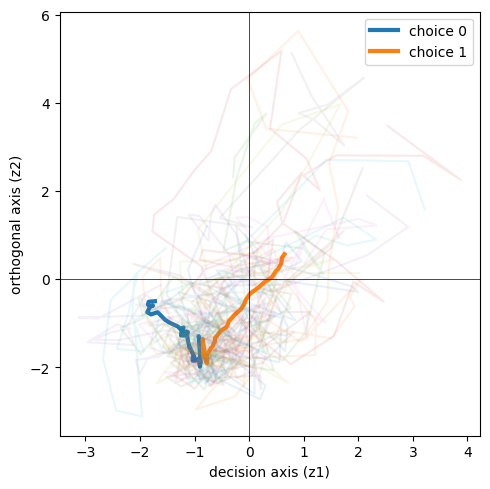

In [60]:
plt.figure(figsize=(5, 5))

for choice in [0, 1]:
    idx = (y == choice)
    # plot mean trajectory
    mean_traj = Z[idx].mean(axis=0)
    plt.plot(mean_traj[:, 0], mean_traj[:, 1],
             lw=3, label=f"choice {choice}")
    # plot individual trials (light)
    idx = np.random.randint(0, len(Z), size=10)
    for z in Z[idx]:
        plt.plot(z[:, 0], z[:, 1], alpha=0.1)

plt.axvline(0, color="k", lw=0.5)
plt.axhline(0, color="k", lw=0.5)
plt.xlabel("decision axis (z1)")
plt.ylabel("orthogonal axis (z2)")
plt.legend()
plt.tight_layout()
plt.show()

### Decoder with MLP

In [83]:
train_steps = np.arange(30, 40) #this is what I've been using for most of the experiments
# train_steps = np.array([39])

act = train_ea[:, train_steps]
act = act.reshape(*act.shape[:-3], -1)
act = act.reshape(-1, act.shape[-1])

test_act = test_ea[:, train_steps]
test_act = test_act.reshape(*test_act.shape[:-3], -1)
test_act = test_act.reshape(-1, test_act.shape[-1])

#labels - decisions

train_dec_repeated = torch.tensor(train_decisions).repeat_interleave(len(train_steps))
test_dec_repeated = torch.tensor(test_decisions).repeat_interleave(len(train_steps))
decoder_train_labels = train_dec_repeated
decoder_test_labels = test_dec_repeated

In [84]:
decoder_args = {
    "hidden": 32,
    "task": "multiclass",
    "epochs": 25,
    "dropout": 0.2,
    "lr": 4e-5,
    "bs": 256
}

# decoder_args = {
#     "hidden": 32,
#     "task": "multiclass",
#     "epochs": 10,
#     "dropout": 0.1,
#     "lr": 2e-5,
#     "bs": 256
# }

precision = "float32"

decoder_model, results = train_mlp_decoder(
    torch.tensor(act, dtype=torch.float32),
    decoder_train_labels,
    torch.tensor(test_act, dtype=torch.float32),
    decoder_test_labels,
    **decoder_args
)

print(results)

100%|██████████| 25/25 [00:26<00:00,  1.05s/it]

{'best_val_loss': 0.07542790099978447, 'best_epoch': 25}


In [85]:
# test multiclass or binary tasks
with torch.no_grad():
    logits = decoder_model(torch.tensor(act, dtype=torch.float32).to(device))      # [N, 8]
    pred = logits.argmax(1)
    
    wrong = 0
    for i in range(len(pred)):
        if pred[i] != decoder_train_labels[i]:
            wrong += 1
    print(f"Train acc: {1-(wrong/len(pred))}")
        
    logits = decoder_model(torch.tensor(test_act, dtype=torch.float32).to(device))      # [N, 8]
    pred = logits.argmax(1)
        
    wrong = 0
    for i in range(len(pred)):
        if pred[i] != decoder_test_labels[i]:
            wrong += 1
    print(f"Val acc: {1-(wrong/len(pred))}")

Train acc: 1.0
Val acc: 0.975609756097561


### Fit PCA

In [86]:
# X: [N, D]
start_idx = 0
end_idx = 40

#TRAIN
pca_acts = train_ea[:, start_idx:end_idx]
decisions = train_decisions

#TEST
# pca_acts = test_ea[:, start_idx:end_idx]
# decisions = test_decisions

num_samples = len(pca_acts)

pca_acts = pca_acts.reshape(*pca_acts.shape[:-3], -1)


#### Project Into Decoding Space if desired

In [87]:
pca_acts = pca_acts.reshape(-1, pca_acts.shape[-1])

# Process in batches to avoid OOM
batch_size = 1024
hidden_list = []
with torch.no_grad():
    for i in range(0, pca_acts.shape[0], batch_size):
        batch = pca_acts[i:i+batch_size]
        batch_hidden = hidden_from_mlp(decoder_model, torch.tensor(batch, dtype=torch.float32).to(device), apply_relu=True)
        hidden_list.append(batch_hidden.cpu())
pca_acts_hidden = torch.cat(hidden_list, dim=0).numpy()
pca_acts = pca_acts_hidden.reshape(num_samples, end_idx-start_idx, decoder_args["hidden"])

In [106]:
p = PCTrajectoryPlotter(max_components=3)

# Train set (what you used to pass to plot_PC_trajectories)
p.fit(pca_acts, decisions, balance_for_fit=False, collapse_to_class_means=False)

#### Plot

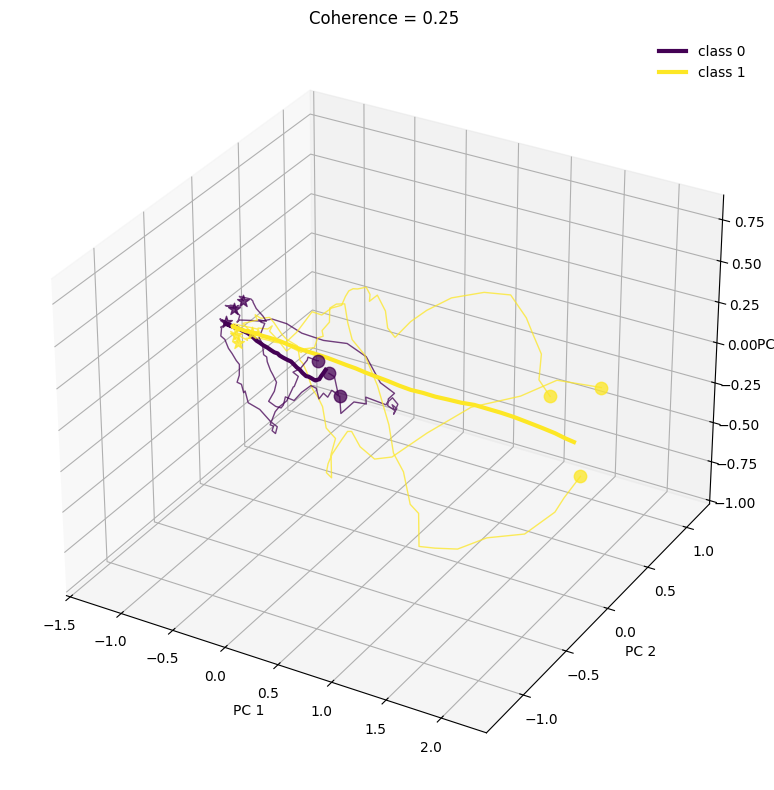

In [82]:
Z = p.plot(
    pca_acts[:, 2:], decisions,
    overlay_examples_k=3,
    overlay_mode="closest",     # 'closest' | 'farthest' | 'random'
    overlay_classes=None,       # None => all classes
    plot_all_endpoints=False,    # scatter ENDPOINTS for all trials
    per_class_mean=True,
    plot_trajectory=False,
    title="Coherence = 0.25",
    alpha=0.75,
    collapse_to_class_means=False,
    extra_point_timestep=39,
    n_components=3,
    return_data=True
)

In [101]:
pca_acts.shape

(532, 40, 32)

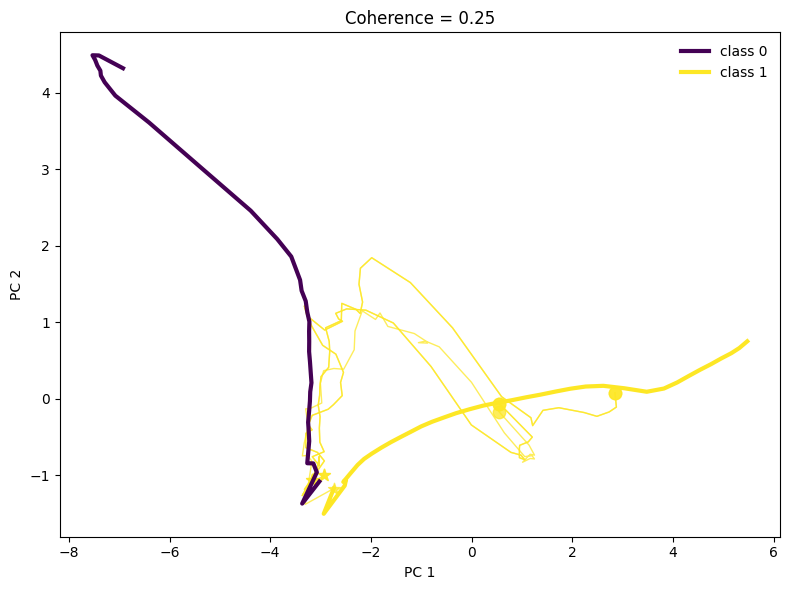

In [108]:
# showing what happens with error trials

random_idx = np.random.randint(0, len(error_trials), size=5)
selected_trials = error_trials[random_idx]
Z = p.plot(
    pca_acts[:, 2:], decisions,
    overlay_examples_k=0,
    overlay_mode="closest",     # 'closest' | 'farthest' | 'random'
    overlay_classes=None,       # None => all classes
    plot_all_endpoints=False,    # scatter ENDPOINTS for all trials
    per_class_mean=True,
    plot_trajectory=False,
    title="Coherence = 0.25",
    alpha=0.75,
    collapse_to_class_means=False,
    n_components=2,
    return_data=True,
    selected_trials=selected_trials
)


## Analyze Dynamics

In [51]:
def rotate_45(trajs, normalize_axes=False, eps=1e-12, clockwise=False):
    """
    Rotate (d,z) trajectories by ±45°.

    Conventions:
        - Input columns: [...,0]=d (x-axis), [...,1]=z (y-axis)
        - clockwise=False: +45° (counterclockwise) rotation
        - clockwise=True:  -45° (clockwise) rotation

    Args:
        trajs: (N, T, 2) array with columns [...,0]=d and [...,1]=z
        normalize_axes: if True, z-score d and z across all points before rotation
        clockwise: if True, rotate by -45° instead of +45°
    Returns:
        trajs_rot: (N, T, 2) rotated coordinates
    """
    X = np.asarray(trajs)
    assert X.ndim == 3 and X.shape[2] == 2, "trajs must be (N,T,2)"

    d = X[..., 0]
    z = X[..., 1]

    if normalize_axes:
        d = (d - d.mean()) / (d.std() + eps)
        z = (z - z.mean()) / (z.std() + eps)

    inv_sqrt2 = 1.0 / np.sqrt(2.0)
    c = inv_sqrt2
    s = inv_sqrt2

    # Rotation matrix R(theta) applied to [d, z]^T:
    # [x']   [ c  -s] [d]
    # [y'] = [ s   c] [z]
    #
    # For theta = -45° (clockwise), just flip the sign of s.
    if clockwise:
        s = -s

    S1 = c * d - s * z
    S2 = s * d + c * z

    return np.stack([S1, S2], axis=-1)


# --------------------------------------------------------
# 2) Linearize in (S1,S2) around the decision boundary
#     (where |S1 - S2| is small; i.e., near the separatrix)
# --------------------------------------------------------
def linearize_in_S_space(trajs_S, dt=1.0, diff_band=0.05,
                         slow_quantile=0.1, neighborhood_radius=0.1,
                         min_samples=200, difference_method="central_difference"):
    """
    Linearize 2D dynamics in (S1,S2) near the decision boundary S1≈S2.

    Args:
        trajs_S: (N, T, 2) with columns [...,0]=S1, [...,1]=S2
        dt: time step between frames
        diff_band: selects boundary points where |S1 - S2| <= diff_band
        slow_quantile: among boundary points, keep slowest q-fraction to estimate s*
        neighborhood_radius: radius around s* for local linear fit
        min_samples: minimum samples for the fit (relaxes neighborhood if needed)
    Returns:
        s_star: (2,) estimated boundary slow-point (proxy for saddle)
        A: (2,2) local Jacobian so that  dot{s} ≈ A (s - s_star)
        evals: (2,) eigenvalues of A  [expect one >0, one <0 near saddle]
        evecs: (2,2) eigenvectors (columns) of A
        idx_neigh: (M,) indices of midstep samples used in the fit (flattened)
    """
    S = np.asarray(trajs_S)
    assert S.ndim == 3 and S.shape[2] == 2, "trajs_S must be (N,T,2)"
    N, T, _ = S.shape

    # midstep states & velocities

    if difference_method == "central_difference":
        dS = (S[:, 2:, :] - S[:, :-2, :]) / dt      # (N, T-2, 2)
        Smid = 0.5 * (S[:, 1:-1, :] + S[:, 2:, :])     # (N, T-2, 2)
    else:
        dS = (S[:, 1:, :] - S[:, :-1, :]) / dt      # (N, T-1, 2)
        Smid = 0.5 * (S[:, 1:, :] + S[:, :-1, :])     # (N, T-1, 2)

    # flatten across trials/time
    Sm = Smid.reshape(-1, 2)                      # positions
    dSm = dS.reshape(-1, 2)                       # velocities

    # boundary selection: |S1 - S2| small
    diff = Sm[:, 0] - Sm[:, 1]
    band_mask = np.abs(diff) <= diff_band
    if not np.any(band_mask):
        raise ValueError("No samples found near boundary; increase diff_band.")

    # pick slow points in the band to locate s*
    speeds = np.linalg.norm(dSm[band_mask], axis=1)
    q = max(1, int(np.ceil(slow_quantile * speeds.size)))
    slow_idx_band = np.argsort(speeds)[:q]
    slow_points = Sm[band_mask][slow_idx_band]
    s_star = slow_points.mean(axis=0)             # proxy for saddle location

    # local neighborhood around s*
    deltas = Sm - s_star[None, :]
    radii = np.linalg.norm(deltas, axis=1)
    neigh_mask = radii <= neighborhood_radius
    if neigh_mask.sum() < min_samples:
        # relax: take closest points until min_samples (or 2% of data)
        order = np.argsort(radii)
        take = max(min_samples, int(0.02 * Sm.shape[0]))
        neigh_mask = np.zeros_like(radii, dtype=bool)
        neigh_mask[order[:take]] = True

    ΔS = deltas[neigh_mask]    # (M,2)
    dS_loc = dSm[neigh_mask]   # (M,2)
    if ΔS.shape[0] < 2:
        raise ValueError("Insufficient neighborhood samples to fit A.")

    # linear fit with zero bias at s*:  dS ≈ A (S - s*)
    A_T, *_ = np.linalg.lstsq(ΔS, dS_loc, rcond=None)
    A = A_T.T

    evals, evecs = np.linalg.eig(A)
    idx_neigh = np.where(neigh_mask)[0]
    return s_star, A, evals, evecs, idx_neigh


In [52]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

def midpts_and_vel(trajs_S, dt=1.0, difference_method="central_difference"):
    if difference_method == "central_difference":
        Sm  = 0.5*(trajs_S[:,1:-1,:] + trajs_S[:,2:,:]).reshape(-1, 2)
        dSm = (trajs_S[:,2:,:] - trajs_S[:,:-2,:]).reshape(-1, 2) / (2.0*dt)
    else:
        Sm  = 0.5*(trajs_S[:,1:,:] + trajs_S[:,:-1,:]).reshape(-1, 2)
        dSm = (trajs_S[:,1:,:] - trajs_S[:,:-1,:]).reshape(-1, 2) / dt
    return Sm, dSm

def local_fixed_point(
    S_trajs,
    dt=1.0,
    diff_band=0.05,
    min_samples=200,
    difference_method="central_difference",
    init_mode="band",              # 'band' | 'global' | 'around'
    center=None,                   # (x,y) for 'around'
    radius=None,                   # defaults to diff_band
    nbhd_frac=0.02,
    damp=1e-6,
    lambda_center=0.0,             # >=0; adds prior to keep s* near center (only used if init_mode='around')
    around_dilate=1.0              # multiply radius for the *final* linearization neighborhood (>=1.0)
):
    """
    Returns: s_star, A, evals, evecs, take2_indices
    """
    S = np.asarray(S_trajs); assert S.ndim==3 and S.shape[2]==2
    Sm, dSm = midpts_and_vel(S, dt=dt, difference_method=difference_method)
    speeds_all = np.linalg.norm(dSm, axis=1)

    # ----- build pool of candidate points -----
    if init_mode == "band":
        band = np.abs(Sm[:,0] - Sm[:,1]) <= diff_band
        if not np.any(band):
            raise ValueError("No samples satisfy |S1-S2| <= diff_band.")
        pool_idx = np.where(band)[0]

    elif init_mode == "global":
        pool_idx = np.arange(Sm.shape[0])

    elif init_mode == "around":
        if center is None:
            raise ValueError("Provide center=(x,y) for init_mode='around'.")
        r = diff_band if radius is None else float(radius)
        center = np.asarray(center, float).reshape(1,2)
        in_ball = np.linalg.norm(Sm - center, axis=1) <= r
        if not np.any(in_ball):
            raise ValueError("No samples within 'around' radius; increase radius or move center.")
        pool_idx = np.where(in_ball)[0]
    else:
        raise ValueError("init_mode must be 'band','global','around'.")

    # ----- provisional center from slowest points INSIDE pool -----
    k = max(50, min_samples)
    slow_ord = np.argsort(speeds_all[pool_idx])[:min(k, len(pool_idx))]
    center_est = Sm[pool_idx[slow_ord]].mean(0)

    # ----- neighborhood for affine fit -----
    # IMPORTANT: if 'around', KEEP it local by restricting to pool_idx
    if init_mode == "around":
        base_idx = pool_idx
    else:
        base_idx = np.arange(Sm.shape[0])

    radii = np.linalg.norm(Sm[base_idx] - center_est, axis=1)
    M1 = max(min_samples, int(nbhd_frac * Sm.shape[0]))
    take_local = base_idx[np.argsort(radii)[:M1]]
    S_loc, dS_loc = Sm[take_local], dSm[take_local]

    # ----- affine fit dS ≈ A_aff S + b_aff -----
    S_aug = np.column_stack([S_loc, np.ones(len(S_loc))])
    AB, *_ = np.linalg.lstsq(S_aug, dS_loc, rcond=None)
    A_aff = AB[:2, :].T
    b_aff = AB[2, :]

    # ----- fixed point solve -----
    # unconstrained: s* = -A^{-1} b
    # constrained (trust-region to center_est or given center):
    try:
        if not (init_mode == "around" and lambda_center > 0):
            s_star = -np.linalg.solve(A_aff, b_aff)
        else:
            c = center.ravel() if center is not None else center_est
            AtA = A_aff.T @ A_aff
            rhs = -A_aff.T @ b_aff + lambda_center * c
            s_star = np.linalg.solve(AtA + lambda_center * np.eye(2), rhs)
    except np.linalg.LinAlgError:
        # ridge-stabilized fallback
        s_star = np.linalg.lstsq(A_aff + damp*np.eye(2), -b_aff, rcond=None)[0]

    # ----- final linearization neighborhood (keep local for 'around') -----
    if init_mode == "around":
        # allow a slightly larger ring but still local
        r2 = (diff_band if radius is None else float(radius)) * float(max(1.0, around_dilate))
        in_ring = np.linalg.norm(Sm - s_star, axis=1) <= r2
        take2 = np.where(in_ring)[0]
        if take2.size < min_samples:
            # fallback to nearest points within base_idx
            print("Fallback to nearest points within base_idx")
            d2 = np.linalg.norm(Sm[base_idx] - s_star, axis=1)
            take2 = base_idx[np.argsort(d2)[:min_samples]]
            s_star = Sm[take2].mean(axis=0)
    else:
        d2 = np.linalg.norm(Sm - s_star, axis=1)
        M2 = max(min_samples, int(nbhd_frac * Sm.shape[0]))
        take2 = np.argsort(d2)[:M2]

    ΔS = Sm[take2] - s_star
    dS2 = dSm[take2]
    A_T, *_ = np.linalg.lstsq(ΔS, dS2, rcond=None)
    A = A_T.T

    evals, evecs = np.linalg.eig(A)
    return s_star, A, evals, evecs, take2

# ---------- empirical field on a grid ----------
def compute_empirical_field_S(
    trajs_S, dt=1.0, nbins=30, min_count=5, extent=None, difference_method="central_difference"
):
    """
    Build an averaged empirical vector field on a uniform grid using the SAME
    midpoints/velocities as everywhere else.
    """
    S1 = trajs_S[..., 0]; S2 = trajs_S[..., 1]
    if difference_method == "central_difference":
        dS1 = (S1[:, 2:] - S1[:, :-2]) / (2.0 * dt)
        dS2 = (S2[:, 2:] - S2[:, :-2]) / (2.0 * dt)
        S1m = 0.5 * (S1[:, 1:-1] + S1[:, 2:])
        S2m = 0.5 * (S2[:, 1:-1] + S2[:, 2:])
    else:
        dS1 = (S1[:, 1:] - S1[:, :-1]) / dt
        dS2 = (S2[:, 1:] - S2[:, :-1]) / dt
        S1m = 0.5 * (S1[:, 1:] + S1[:, :-1])
        S2m = 0.5 * (S2[:, 1:] + S2[:, :-1])

    s1_all, s2_all = S1m.ravel(), S2m.ravel()
    u_all,  v_all  = dS1.ravel(), dS2.ravel()

    # auto extent with a small pad (robust to outliers)
    if extent is None:
        s1min, s1max = np.percentile(s1_all, [2, 98])
        s2min, s2max = np.percentile(s2_all, [2, 98])
        pad1 = 0.06 * (s1max - s1min + 1e-12)
        pad2 = 0.06 * (s2max - s2min + 1e-12)
        s1min, s1max = s1min - pad1, s1max + pad1
        s2min, s2max = s2min - pad2, s2max + pad2
    else:
        (s1min, s1max), (s2min, s2max) = extent

    s1_edges = np.linspace(s1min, s1max, nbins + 1)
    s2_edges = np.linspace(s2min, s2max, nbins + 1)

    xi = np.clip(((s1_all - s1min) / (s1max - s1min) * nbins).astype(int), 0, nbins - 1)
    yi = np.clip(((s2_all - s2min) / (s2max - s2min) * nbins).astype(int), 0, nbins - 1)

    U = np.zeros((nbins, nbins)); V = np.zeros((nbins, nbins)); C = np.zeros((nbins, nbins), int)
    for i in range(s1_all.size):
        U[yi[i], xi[i]] += u_all[i]
        V[yi[i], xi[i]] += v_all[i]
        C[yi[i], xi[i]] += 1

    mask = C >= min_count
    U[mask] /= C[mask]; V[mask] /= C[mask]

    s1_cent = 0.5 * (s1_edges[:-1] + s1_edges[1:])
    s2_cent = 0.5 * (s2_edges[:-1] + s2_edges[1:])
    S1g, S2g = np.meshgrid(s1_cent, s2_cent)

    return dict(
        S1g=S1g, S2g=S2g, U=U, V=V, mask=mask,
        s1_edges=s1_edges, s2_edges=s2_edges,
        extent=((s1min, s1max), (s2min, s2max)),
        difference_method=difference_method
    )


# ---------- combined field + local linearization plot ----------
def plot_combined_vector_and_linearization(
    trajs_S, dt=1.0, nbins=30, min_count=5, density_bg=True, cmap_bg="Greys",
    s_star=None, A=None, evals=None, evecs=None, idx_neigh=None,
    field=None, field_extent=0.15, field_res=17, eigen_scale=0.08,
    title="Empirical field + local linearization (S1,S2)",
    difference_method="central_difference",
    around_center=None, around_radius=None,
    show_neighborhood=False, num_trajs_to_plot=15
):
    # compute or reuse the exact same field
    if field is None:
        field = compute_empirical_field_S(trajs_S, dt, nbins, min_count,
                                          extent=None, difference_method=difference_method)
    else:
        assert field.get("difference_method", difference_method) == difference_method, \
            f"Field computed with {field.get('difference_method')} but plot asked for {difference_method}"

    S1g, S2g, U, V, mask = field["S1g"], field["S2g"], field["U"], field["V"], field["mask"]
    (s1min, s1max), (s2min, s2max) = field["extent"]
    s1_edges, s2_edges = field["s1_edges"], field["s2_edges"]

    # mid-step cloud matching the method
    Sm, _ = midpts_and_vel(trajs_S, dt=dt, difference_method=difference_method)
    s1_all, s2_all = Sm[:, 0], Sm[:, 1]

    fig, ax = plt.subplots(figsize=(6, 6))
    if density_bg:
        H, _, _ = np.histogram2d(s1_all, s2_all, bins=[s1_edges, s2_edges])
        ax.imshow(H.T, origin="lower", extent=[s1min, s1max, s2min, s2max],
                  cmap=cmap_bg, alpha=0.28, interpolation="bilinear")

    Uplot, Vplot = np.where(mask, U, 0.0), np.where(mask, V, 0.0)
    mag = np.hypot(Uplot[mask], Vplot[mask]); scale = np.nanpercentile(mag, 95) or 1.0
    ax.quiver(S1g[mask], S2g[mask], Uplot[mask]/scale, Vplot[mask]/scale,
              angles="xy", scale_units="xy", scale=1.0,
              width=0.002, headwidth=2.5, headlength=3.5, alpha=0.9, color="tab:blue",
              label="empirical field")

    # overlays
    if around_center is not None and around_radius is not None:
        circ = Circle(tuple(around_center), float(around_radius),
                      fill=False, lw=1.6, ls="--", color="orange", alpha=0.95)
        ax.add_patch(circ)
        ax.scatter([around_center[0]], [around_center[1]], s=40, color="orange", zorder=5, label="around center")

    if s_star is not None:
        ax.scatter([s_star[0]], [s_star[1]], s=60, color="crimson", zorder=5, label="s*")

    if show_neighborhood and (idx_neigh is not None):
        neigh_mask = np.zeros(Sm.shape[0], dtype=bool); neigh_mask[idx_neigh] = True
        ax.scatter(Sm[neigh_mask, 0], Sm[neigh_mask, 1], s=8, color="tab:purple",
                   alpha=0.5, label="fit neighborhood", zorder=4)

    if (A is not None) and (evals is not None) and (evecs is not None) and (s_star is not None):
        # eigen directions at s*
        span = max(s1max - s1min, s2max - s2min)
        for lam, vec in zip(np.real(evals), np.real(evecs.T)):
            v = vec / (np.linalg.norm(vec) + 1e-12)
            length = eigen_scale * span
            color = "tomato" if lam > 0 else "teal"
            ax.arrow(s_star[0], s_star[1], length*v[0], length*v[1],
                     head_width=0.02*span, head_length=0.03*span,
                     length_includes_head=True, color=color, alpha=0.95, lw=2.0, zorder=6)
        ax.plot([], [], color="tomato", lw=2, label="unstable eigvec (λ>0)")
        ax.plot([], [], color="teal",   lw=2, label="stable eigvec (λ<0)")
    
    # --- overlay sample trajectories ---
    alpha_traj = 0.5                # transparency

    # pick random trajectories
    N = trajs_S.shape[0]
    idx = np.random.choice(N, size=min(num_trajs_to_plot, N), replace=False)

    for k in idx:
        S1_traj = trajs_S[k,:,0]
        S2_traj = trajs_S[k,:,1]
        ax.plot(S1_traj, S2_traj, lw=1.0, alpha=alpha_traj, color="tab:gray")

    ax.axhline(0, color='k', lw=0.6, alpha=0.25); ax.axvline(0, color='k', lw=0.6, alpha=0.25)
    buffer = 0.1 * max(s1max - s1min, s2max - s2min)
    ax.set_xlim(s1min - buffer, s1max + buffer)
    ax.set_ylim(s2min - buffer, s2max + buffer)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("S1"); ax.set_ylabel("S2"); ax.set_title(title)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(frameon=False, loc="best")
    plt.tight_layout(); plt.show()

def find_slowest_saddle_in_area(
    trajs_S,
    *,
    dt=1.0,
    difference_method="central_difference",
    # define ONE area:
    circle_center=None,          # (x, y)
    circle_radius=None,          # float
    box_extent=None,             # ((s1min, s1max), (s2min, s2max))
    # candidate selection:
    candidate_frac=0.02,         # slowest X% inside area
    candidate_max=500,           # cap on candidates
    # local fit (passed into local_fixed_point):
    search_radius=0.25,
    min_samples=200,
    nbhd_frac=0.02,
    damp=1e-6,
    lambda_center=0.0,           # keep 0.0 for “post-facto constriction”
    around_dilate=1.25,
    # eigenvalue test:
    imag_tol=1e-3
):
    """
    Returns the first slow candidate inside the area whose local linearization is a saddle:
    (s_star, A, evals, evecs, used_idx) — identical shape/order to local_fixed_point.
    Raises RuntimeError if none found among the candidates.
    """
    # --- midpoints & speeds (match your other functions) ---
    Sm, dSm = midpts_and_vel(trajs_S, dt=dt, difference_method=difference_method)
    speeds = np.linalg.norm(dSm, axis=1)

    # --- area mask (choose exactly one area) ---
    use_circle = (circle_center is not None and circle_radius is not None)
    use_box = (box_extent is not None)
    if use_circle == use_box:
        raise ValueError("Specify exactly one area: (circle_center & circle_radius) OR box_extent.")

    if use_circle:
        c = np.asarray(circle_center, float).reshape(1, 2)
        area_mask = np.linalg.norm(Sm - c, axis=1) <= float(circle_radius)
    else:
        (s1min, s1max), (s2min, s2max) = box_extent
        area_mask = (Sm[:,0] >= s1min) & (Sm[:,0] <= s1max) & (Sm[:,1] >= s2min) & (Sm[:,1] <= s2max)

    idx_area = np.where(area_mask)[0]
    if idx_area.size == 0:
        raise RuntimeError("No samples inside the specified area.")

    # --- pick slow candidate centers inside area ---
    n_cand = max(1, min(int(candidate_frac * idx_area.size), candidate_max))
    cand_idx = idx_area[np.argsort(speeds[idx_area])[:n_cand]]
    cand_centers = Sm[cand_idx]

    # --- try candidates (slowest first); accept first true saddle ---
    for center in cand_centers:
        try:
            s_star, A, evals, evecs, used_idx = local_fixed_point(
                trajs_S,
                dt=dt,
                diff_band=search_radius,
                min_samples=min_samples,
                difference_method=difference_method,
                init_mode="around",
                center=center,
                radius=search_radius,
                nbhd_frac=nbhd_frac,
                damp=damp,
                lambda_center=lambda_center,
                around_dilate=around_dilate
            )
        except ValueError:
            continue  # e.g., not enough samples in radius — try next candidate

        # saddle test: mixed signs in real parts, and nearly-real eigenvalues
        evals = np.asarray(evals)
        re = np.real(evals); im = np.abs(np.imag(evals))
        if np.all(im < imag_tol) and (np.any(re > 0) and np.any(re < 0)):
            return s_star, A, evals, evecs, used_idx

    # none accepted
    raise RuntimeError("No saddle found among slow candidates inside the area.")


s*: [-0.78143546 -1.49547137]
A:
 [[-0.00183898 -0.26818579]
 [-0.02581631  0.39712624]]
evals: [-0.01849725  0.41378451]
mean flow near s*: [-0.0076976   0.02410417]


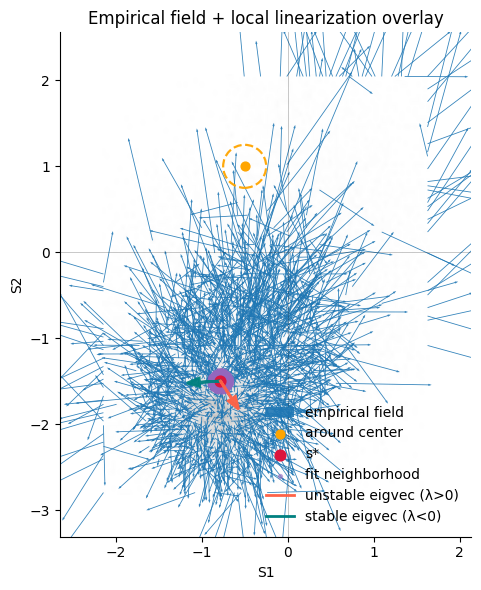

In [53]:
# ---------- example usage (consistent everywhere) ----------
difference_method = "central_difference"  # or "forward_difference"
dt = 1.0
# trajs_S = rotate_45(Z, clockwise=False)  # your data
trajs_S = Z
# trajs_S = trajs_S[:, 4:]

around_center = (-0.5, 1)
around_radius = 0.25

# find local fixed point around a given center
s_star, A, evals, evecs, used_idx = local_fixed_point(
    trajs_S,
    dt=dt,
    diff_band=0.25,
    min_samples=200,
    difference_method=difference_method,
    init_mode="global",
    center=around_center, 
    radius=around_radius,          #how far around each candidate center we collect samples to be the first guess for s*
    nbhd_frac=0.02,
    damp=1e-6,
    lambda_center=0.5,             # >=0; adds prior to keep s* near center (only used if init_mode='around')
    around_dilate=1              # multiply radius for the *final* linearization neighborhood (>=1.0) -- this is for fitting the Jacobian
)
print("s*:", s_star)
print("A:\n", A)
print("evals:", evals)

# diagnostic: mean flow near s* (matches method + dt)
Sm, dSm = midpts_and_vel(trajs_S, dt=dt, difference_method=difference_method)
K = 200
i = np.argsort(np.linalg.norm(Sm - s_star, axis=1))[:K]
print("mean flow near s*:", dSm[i].mean(0))

# plot with overlays
plot_combined_vector_and_linearization(
    trajs_S, dt=dt, nbins=100, min_count=5, density_bg=True,
    s_star=s_star, A=A, evals=evals, evecs=evecs, idx_neigh=used_idx,
    title="Empirical field + local linearization overlay",
    difference_method=difference_method,
    around_center=around_center, around_radius=around_radius,
    show_neighborhood=True, num_trajs_to_plot=0
)


In [ ]:
plt.rcParams['figure.dpi'] = 300


s*: [-1.35296057 -2.10842403]
A:
 [[-0.49921534 -0.43531816]
 [-0.48420839  0.19844519]]
evals: [-0.72698481  0.42621466]
mean flow near s*: [-0.08825859 -0.0630106 ]


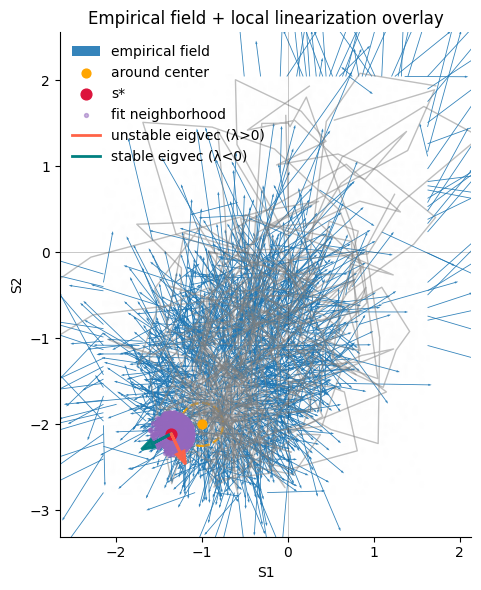

In [55]:
around_center = (-1, -2)
search_radius = 0.25 #how far around each candidate center we collect samples to be the first guess for s*
circle_radius = 0.5  #how far from the center of the circle we collect candidates over the outer loop

difference_method = "central_difference"

s_star, A, evals, evecs, used_idx = find_slowest_saddle_in_area(
    trajs_S,
    dt=0.5,
    difference_method=difference_method,
    circle_center=around_center,
    circle_radius=circle_radius,
    search_radius=search_radius,
    min_samples=200,
    lambda_center=4,           
    around_dilate=1,
)

print("s*:", s_star)
print("A:\n", A)
print("evals:", evals)

# diagnostic: mean flow near s* (matches method + dt)
Sm, dSm = midpts_and_vel(trajs_S, dt=dt, difference_method=difference_method)
K = 200
i = np.argsort(np.linalg.norm(Sm - s_star, axis=1))[:K]
print("mean flow near s*:", dSm[i].mean(0))

# plot with overlays
plot_combined_vector_and_linearization(
    trajs_S, dt=dt, nbins=100, min_count=5, density_bg=True,
    s_star=s_star, A=A, evals=evals, evecs=evecs, idx_neigh=used_idx,
    title="Empirical field + local linearization overlay",
    difference_method=difference_method,
    around_center=around_center, around_radius=search_radius,
    show_neighborhood=True
)


## SINDy